Trækprøver fro ABS, PMMA, og PE

Prerequisites

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import os
import glob
import shutil
import pathlib
import re

Import data and formatting data

In [2]:
#Load dataframe. Data is saved as .xlsx files in the data folder and loaded as Panda DataFrames.
df_abs_F = pd.read_excel('data/abs-F.xlsx')
df_pmma_F= pd.read_excel('data/pmma-F.xlsx')
df_pe_F = pd.read_excel('data/pe-F.xlsx')

df_absN_S_side = pd.read_excel('data/absN-S-side.xlsx')
df_absN_S_top = pd.read_excel('data/absN-S-top.xlsx')
df_absR_S_side = pd.read_excel('data/absR-S-side.xlsx')
df_absR_S_top = pd.read_excel('data/absR-S-top.xlsx')
df_pmma_S_side = pd.read_excel('data/pmma-S-side.xlsx')
df_pmma_S_top = pd.read_excel('data/pmma-S-top.xlsx')
df_pe_S_side = pd.read_excel('data/pe-S-side.xlsx')
df_pe_S_top = pd.read_excel('data/pe-S-top.xlsx')



In [3]:

#Splitting dataframes into sample dataframes
#Each import contains 5 samples, each sample has 4 columns: Time, Displacement, Force, and Load. These are split into 5 dataframes, one for each sample.

#Dealing with negative starting values
def neg_to_zero(df):
    for i in range(0, len(df.columns)):
        df.iloc[:, i] = df.iloc[:, i].apply(lambda x: 0 if x < 0 else x)
    return df

#Convert columns to numeric
def col_to_numeric(df):
    df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
    df['Displacement'] = pd.to_numeric(df['Displacement'], errors='coerce')
    return df


def df_generator(df, df_name: str):
    """
    Splits the dataframe into 5 dataframes, one for each sample. Each sample has 4 columns: Time, Displacement, Force, and Load.
    """
    for i in range(0, int(len(df.columns)/4)):
        df_temp = df.iloc[:, i*4:4+i*4]
        #drop row 1 and 3
        #make row 0 as header
        df_temp.columns = df_temp.iloc[0]
        df_temp = df_temp.drop([0])
        df_temp = df_temp.drop([1])
        df_temp = df_temp.reset_index(drop=True)
        #print(df_temp)
        #make negative values 0
        df_temp = neg_to_zero(df_temp)
        #return df_temp as df with name "df_i_df_name"
        i=i+1
        col_to_numeric(df_temp)
        globals()[f'df_{i}_{df_name}'] = df_temp

In [4]:
#Generate dataframes for each sample

df_generator(df_abs_F, 'abs_f')
df_generator(df_pmma_F, 'pmma_f')
df_generator(df_pe_F, 'pe_f')
df_generator(df_absN_S_side, 'absN_s_side')
df_generator(df_absN_S_top, 'absN_s_top')
df_generator(df_absR_S_side, 'absR_s_side')
df_generator(df_absR_S_top, 'absR_s_top')
df_generator(df_pmma_S_side, 'pmma_s_side')
df_generator(df_pmma_S_top, 'pmma_s_top')
df_generator(df_pe_S_side, 'pe_s_side')
df_generator(df_pe_S_top, 'pe_s_top')

#Check output. Notice that the data indexes continues further than the Load and Displacement columns.
df_1_pmma_s_side


,Load,Displacement,Time,Event
0,0.597193,0.0,0.00,0.0
1,0.597193,0.0,0.01,0.0
2,0.597193,0.0,0.02,0.0
3,0.597193,0.0,0.03,0.0
4,0.597193,0.0,0.04,0.0
...,...,...,...,...
26903,NaN,NaN,NaN,NaN
26904,NaN,NaN,NaN,NaN
26905,NaN,NaN,NaN,NaN
26906,NaN,NaN,NaN,NaN


In [5]:
# Create a list of all the dataframes there are 11 dataframes with 5 samples each
df_list = [
    df_1_abs_f, df_2_abs_f, df_3_abs_f, df_4_abs_f, df_5_abs_f,
    df_1_pmma_f, df_2_pmma_f, df_3_pmma_f, df_4_pmma_f, df_5_pmma_f,
    df_1_pe_f, df_2_pe_f, df_3_pe_f, df_4_pe_f, df_5_pe_f,
    df_1_absN_s_side, df_2_absN_s_side, df_3_absN_s_side, df_4_absN_s_side, df_5_absN_s_side,
    df_1_absN_s_top, df_2_absN_s_top, df_3_absN_s_top, df_4_absN_s_top, df_5_absN_s_top,
    df_1_absR_s_side, df_2_absR_s_side, df_3_absR_s_side, df_4_absR_s_side, df_5_absR_s_side,
    df_1_absR_s_top, df_2_absR_s_top, df_3_absR_s_top, df_4_absR_s_top, df_5_absR_s_top,
    df_1_pmma_s_side, df_2_pmma_s_side, df_3_pmma_s_side, df_4_pmma_s_side, df_5_pmma_s_side,
    df_1_pmma_s_top, df_2_pmma_s_top, df_3_pmma_s_top, df_4_pmma_s_top, df_5_pmma_s_top,
    df_1_pe_s_side, df_2_pe_s_side, df_3_pe_s_side, df_4_pe_s_side, df_5_pe_s_side,
    df_1_pe_s_top, df_2_pe_s_top, df_3_pe_s_top, df_4_pe_s_top, df_5_pe_s_top,
    ]
   
df_names = [
    "df_1_abs_f", "df_2_abs_f", "df_3_abs_f", "df_4_abs_f", "df_5_abs_f",
    "df_1_pmma_f", "df_2_pmma_f", "df_3_pmma_f", "df_4_pmma_f", "df_5_pmma_f",
    "df_1_pe_f", "df_2_pe_f", "df_3_pe_f", "df_4_pe_f", "df_5_pe_f",
    "df_1_absN_s_side", "df_2_absN_s_side", "df_3_absN_s_side", "df_4_absN_s_side", "df_5_absN_s_side",
    "df_1_absN_s_top", "df_2_absN_s_top", "df_3_absN_s_top", "df_4_absN_s_top", "df_5_absN_s_top",
    "df_1_absR_s_side", "df_2_absR_s_side", "df_3_absR_s_side", "df_4_absR_s_side", "df_5_absR_s_side",
    "df_1_absR_s_top", "df_2_absR_s_top", "df_3_absR_s_top", "df_4_absR_s_top", "df_5_absR_s_top",
    "df_1_pmma_s_side", "df_2_pmma_s_side", "df_3_pmma_s_side", "df_4_pmma_s_side", "df_5_pmma_s_side",
    "df_1_pmma_s_top", "df_2_pmma_s_top", "df_3_pmma_s_top", "df_4_pmma_s_top", "df_5_pmma_s_top",
    "df_1_pe_s_side", "df_2_pe_s_side", "df_3_pe_s_side", "df_4_pe_s_side", "df_5_pe_s_side",
    "df_1_pe_s_top", "df_2_pe_s_top", "df_3_pe_s_top", "df_4_pe_s_top", "df_5_pe_s_top",
]

In [6]:
#Dealing with NaN values at the end of the dataframes.
#find points where load is 0, skip first 1000 rows
def find_drop(df):
    # Find the index of the first occurrence of load less than 25
    zero_load_indices = df.index[df['Load'] < 25].tolist()
    # Skip the first 1000 rows
    zero_load_indices = [i for i in zero_load_indices if i > 2970]
    return zero_load_indices[0+1]


def drop_row_after(df, row):
    # Drop the row and all rows after it
    df = df.iloc[:row]
    return df


#drop_row_after for all dataframes
def drop_row_after_all(df_list, df_names):
    for i in range(len(df_list)):
        df_list[i] = drop_row_after(df_list[i], find_drop(df_list[i]))
        globals()[df_names[i]] = df_list[i]


In [7]:
#Dealing with NaN values at the end of the dataframes.
drop_row_after_all(df_list, df_names)


Visualization

In [8]:
#Delete all files in the plots folder
#This is done to avoid overwriting files and to keep the folder clean.
def delete_all_files_in_folder(folder_path):
    # Check if the folder exists
    if os.path.exists(folder_path):
        # Iterate through all files and folders in the directory
        for item in os.listdir(folder_path):
            item_path = os.path.join(folder_path, item)
            try:
                # Delete file
                if os.path.isfile(item_path) or os.path.islink(item_path):
                    os.remove(item_path)
                # Delete directory
                elif os.path.isdir(item_path):
                    shutil.rmtree(item_path)
            except Exception as e:
                print(f"Error deleting {item_path}: {e}")
    else:
        print(f"The folder {folder_path} does not exist.")

    #Create subfolder that takes a name
def create_subfolder(folder_path, subfolder_name):
    # Create the subfolder path
    subfolder_path = os.path.join(folder_path, subfolder_name)
    
    # Check if the subfolder already exists
    if not os.path.exists(subfolder_path):
        # Create the subfolder
        os.makedirs(subfolder_path)
        print(f"Subfolder {subfolder_name} created in {folder_path}.")
    else:
        print(f"Subfolder {subfolder_name} already exists in {folder_path}.")


delete_all_files_in_folder('plots')
create_subfolder('plots', 'individual')
create_subfolder('plots', 'combined')
create_subfolder('plots', 'fracture_points')
create_subfolder('plots', 'boxplots')

Error deleting plots\boxplots: [WinError 5] Access is denied: 'plots\\boxplots'
Error deleting plots\combined: [WinError 5] Access is denied: 'plots\\combined'
Error deleting plots\fracture_points: [WinError 5] Access is denied: 'plots\\fracture_points'
Error deleting plots\individual: [WinError 5] Access is denied: 'plots\\individual'
Subfolder individual already exists in plots.
Subfolder combined already exists in plots.
Subfolder fracture_points already exists in plots.
Subfolder boxplots already exists in plots.


In [9]:
#Create plot for each sample
def plot_single_sample(df, df_name: str="unnamed", save=False):
    # Clean column names
    col_names = [col.strip().lower() for col in df.columns]

    try:
        load_idx = col_names.index("load")
        disp_idx = col_names.index("displacement")
    except ValueError as e:
        raise ValueError(f"Could not find 'Load' or 'Displacement' in columns: {df.columns}") from e

    # Extract the data using column names
    data = df.iloc[:, [disp_idx, load_idx]].astype(float)
    data.columns = ["Displacement", "Load"]

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(data["Displacement"], data["Load"])
    plt.xlabel("Displacement (mm)")
    plt.ylabel("Load (N)")
    plt.title(f"Load vs Displacement - {df_name}")
    plt.grid(True)
    plt.tight_layout()
    if save:
        plt.savefig(f"plots/{df_name}_single_sample.png")
    plt.show()


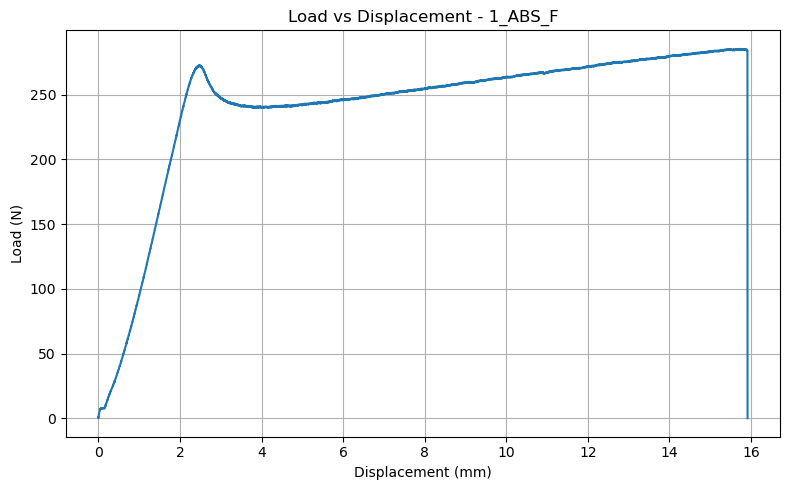

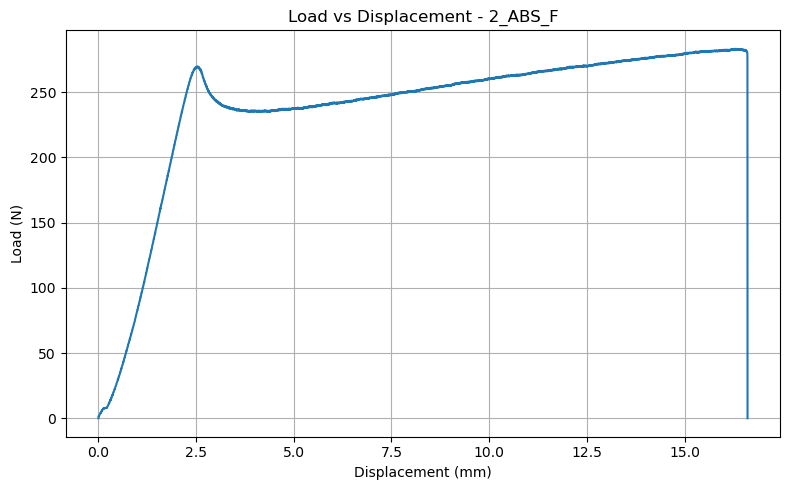

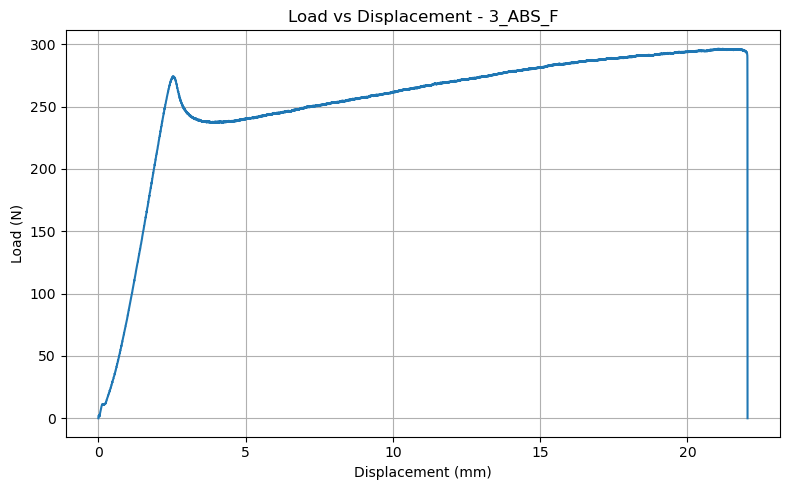

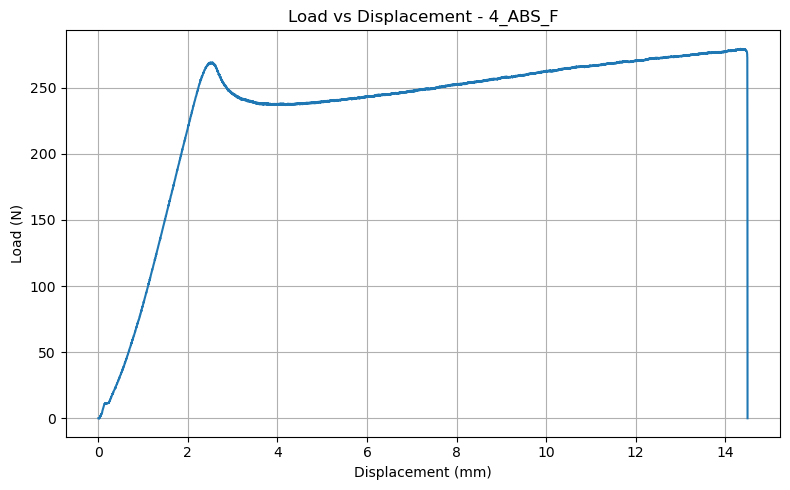

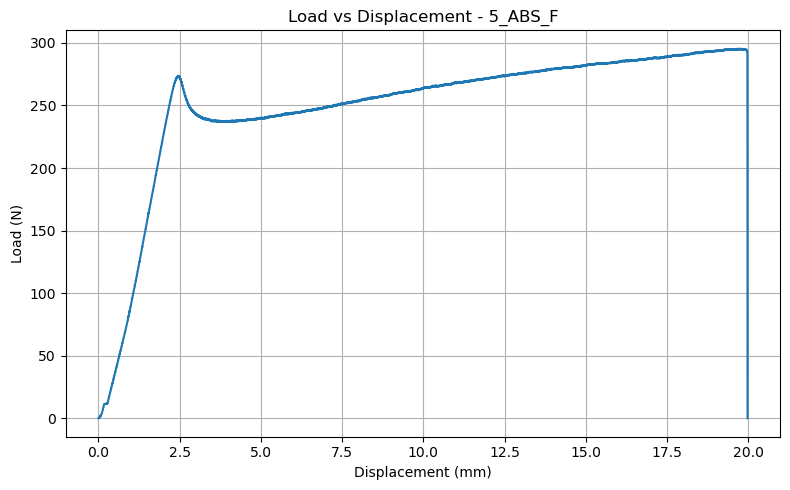

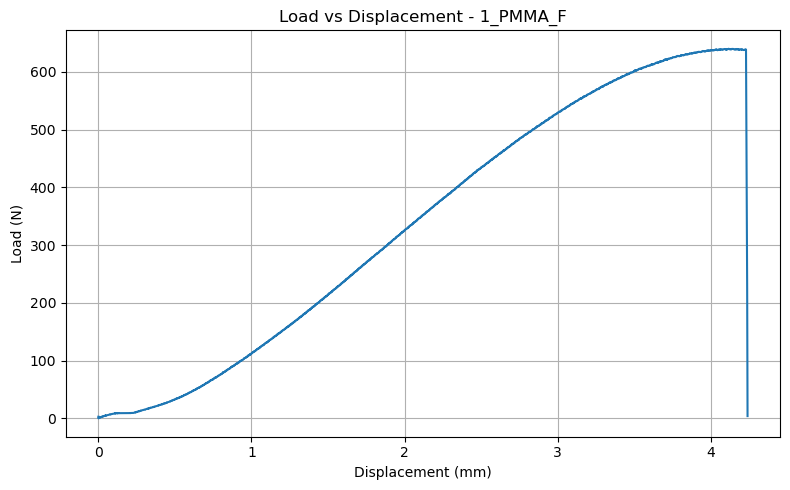

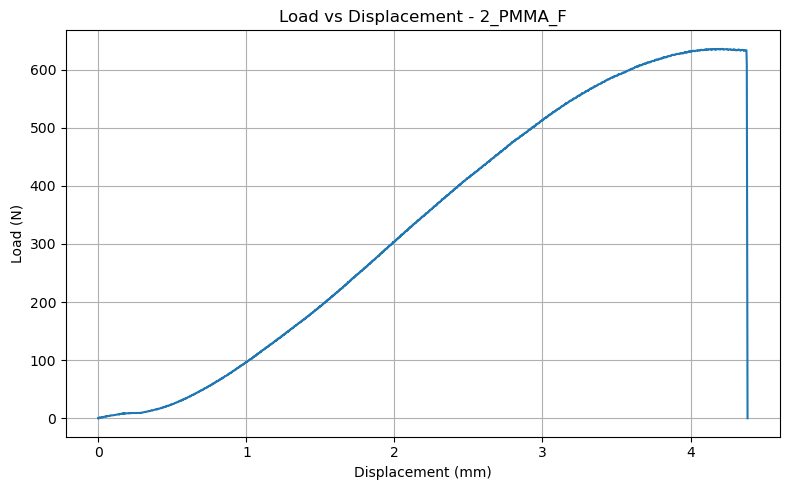

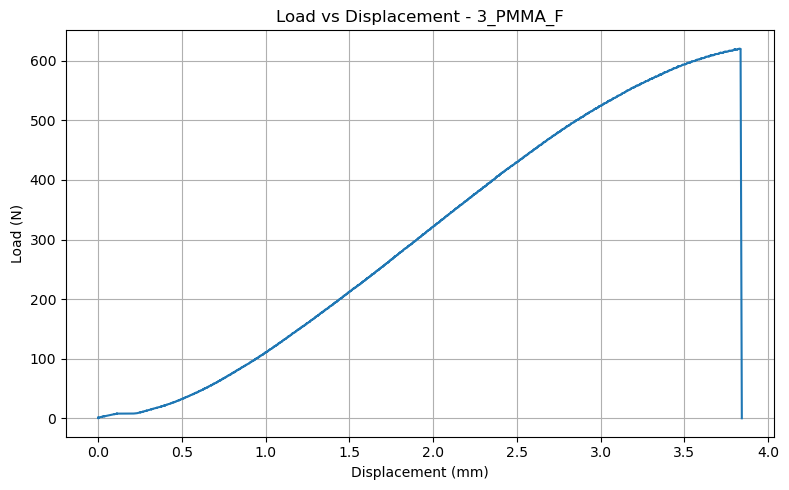

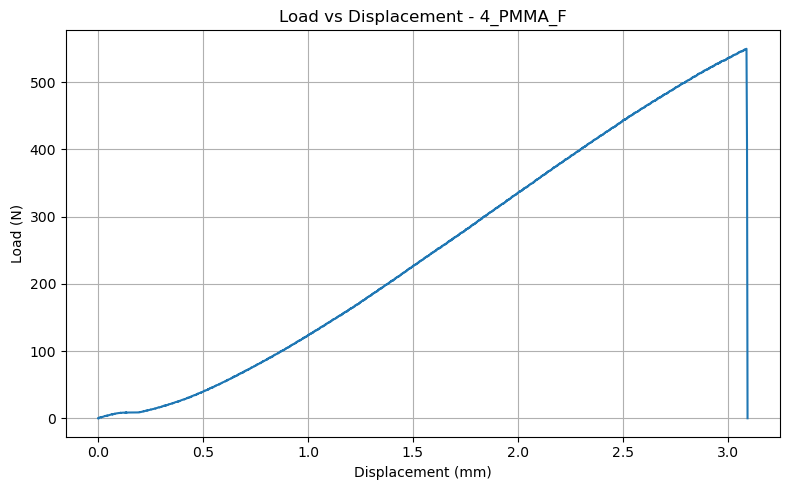

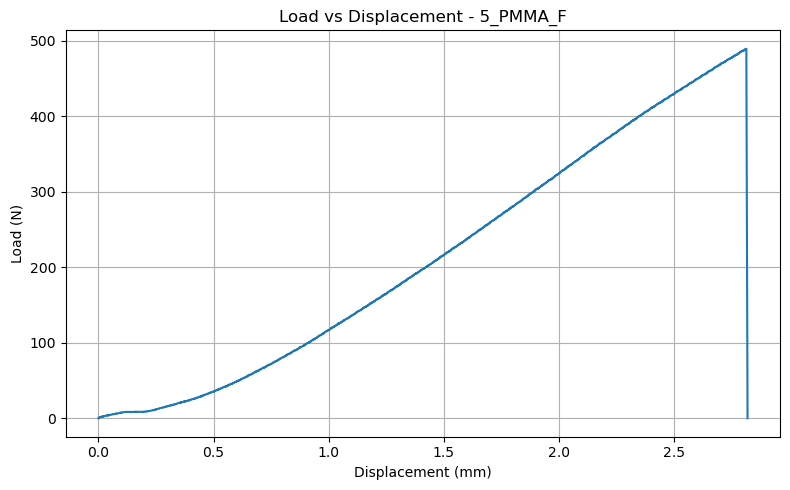

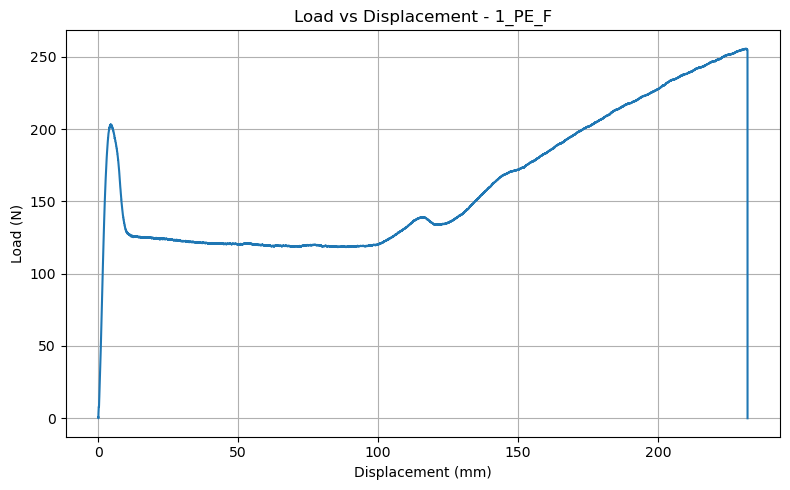

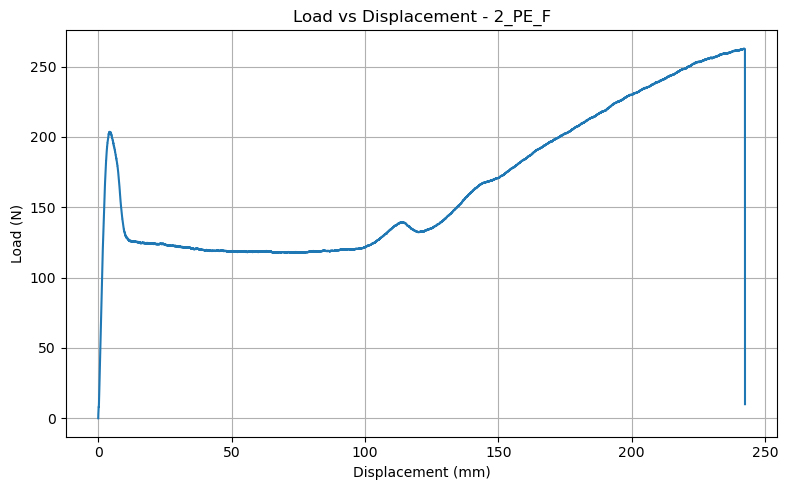

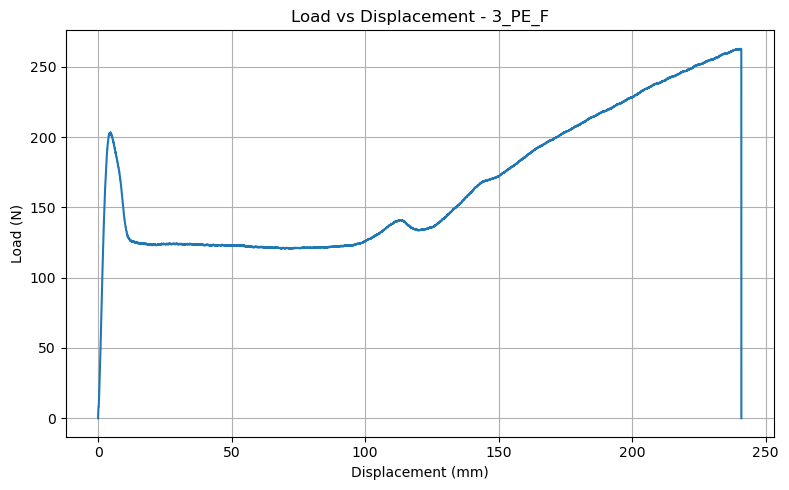

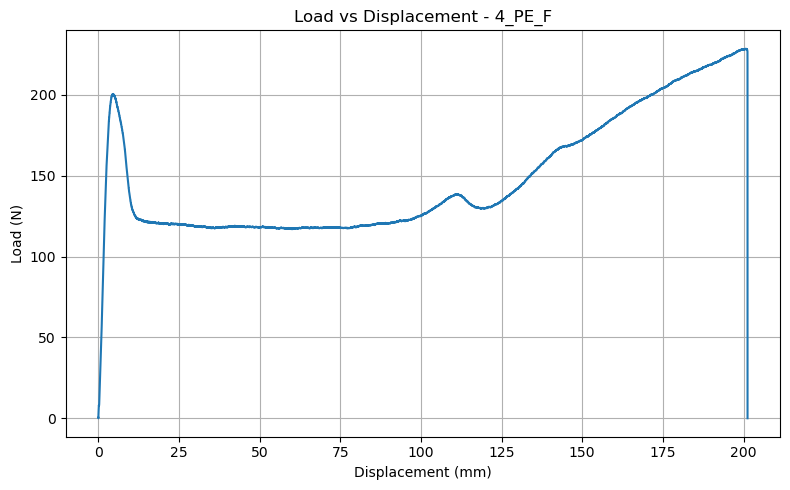

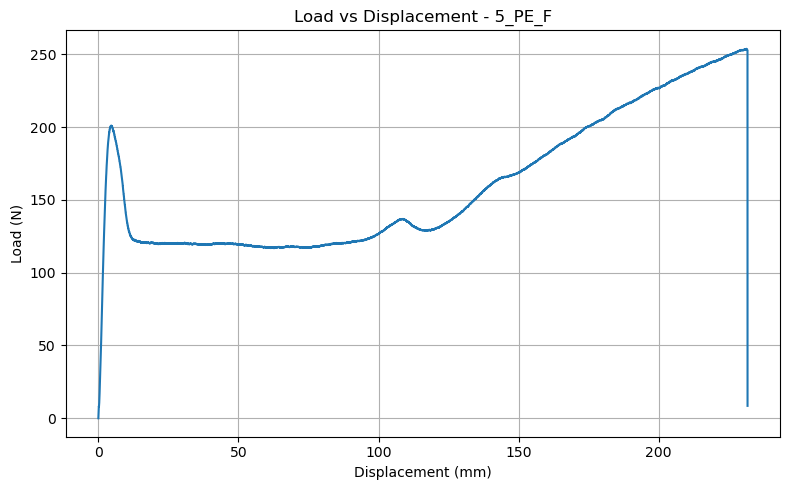

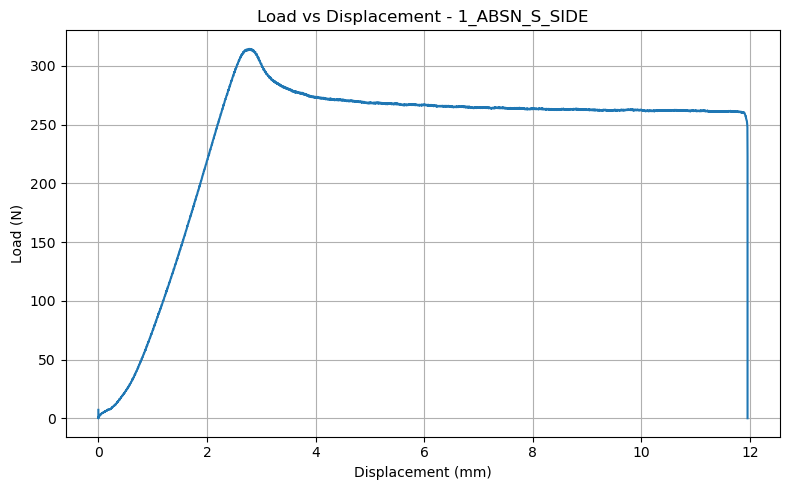

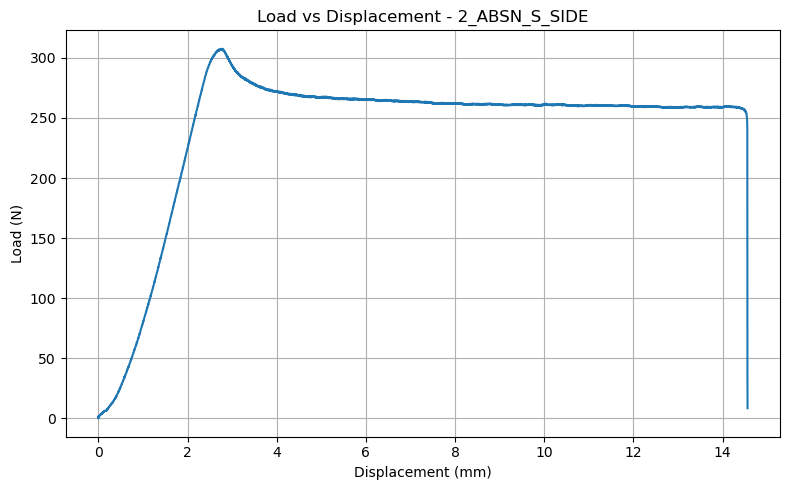

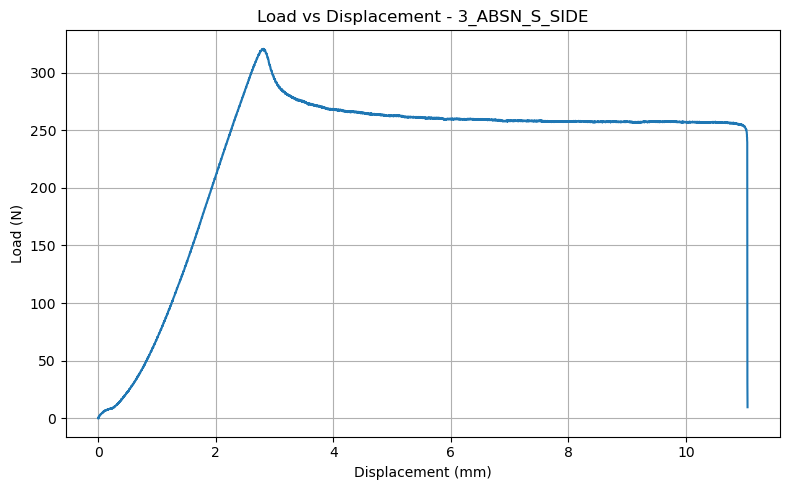

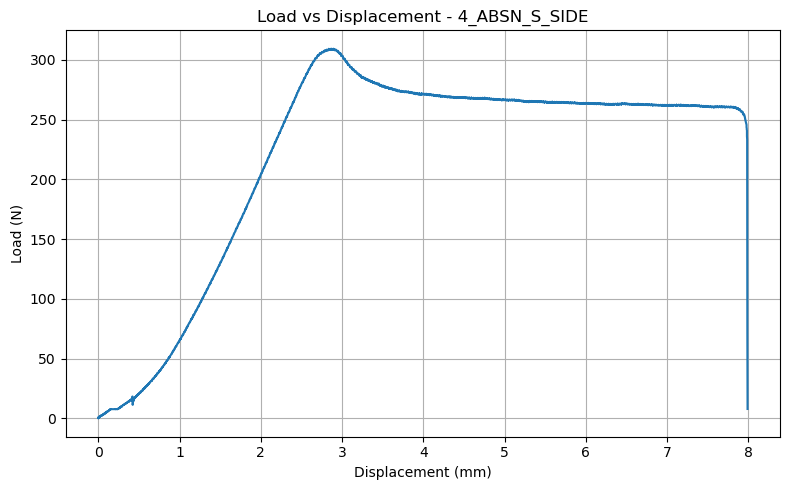

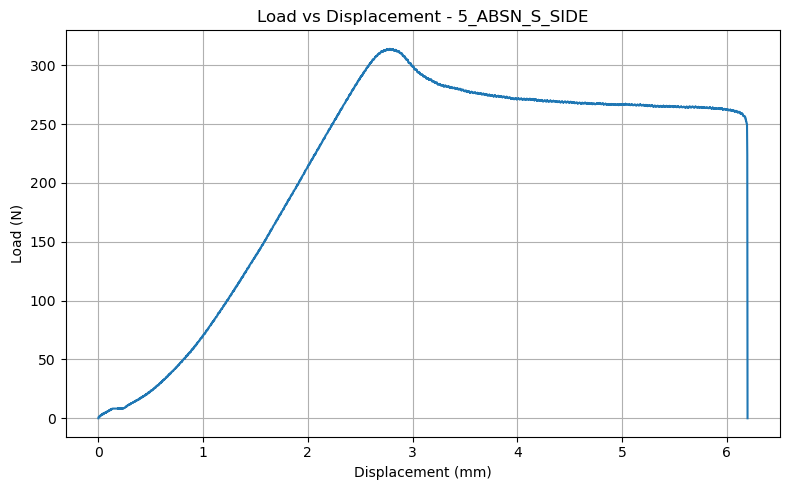

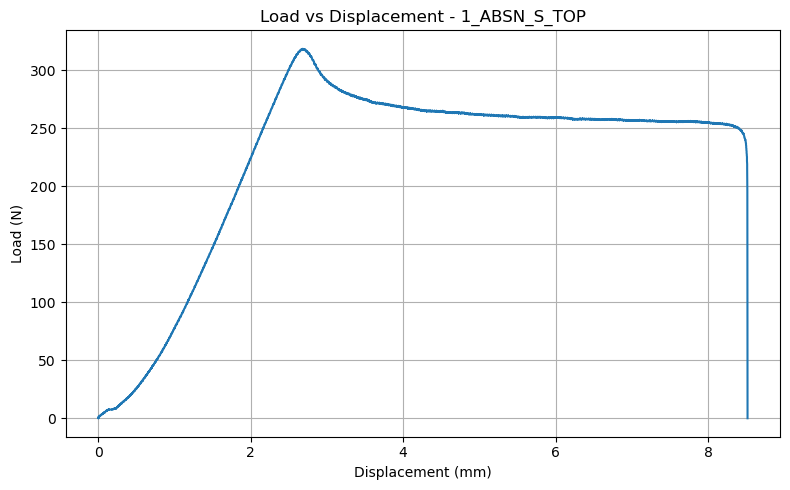

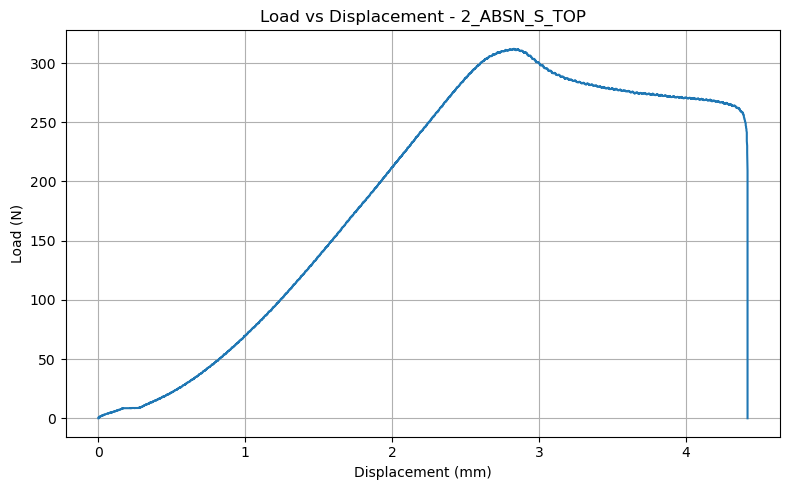

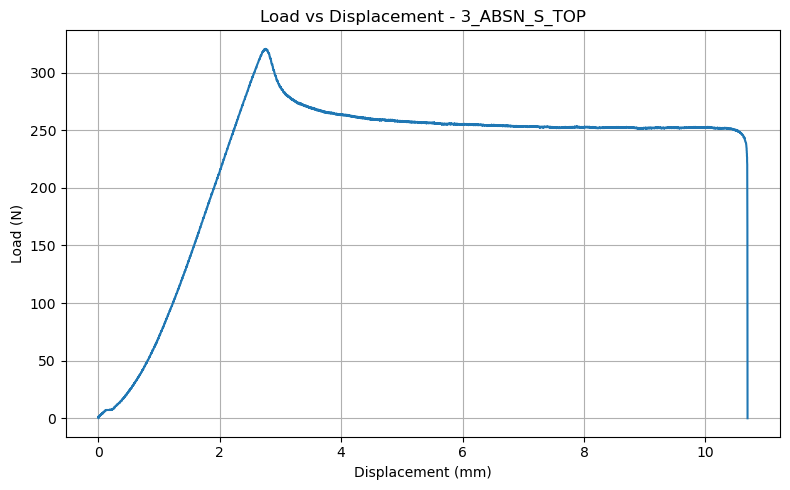

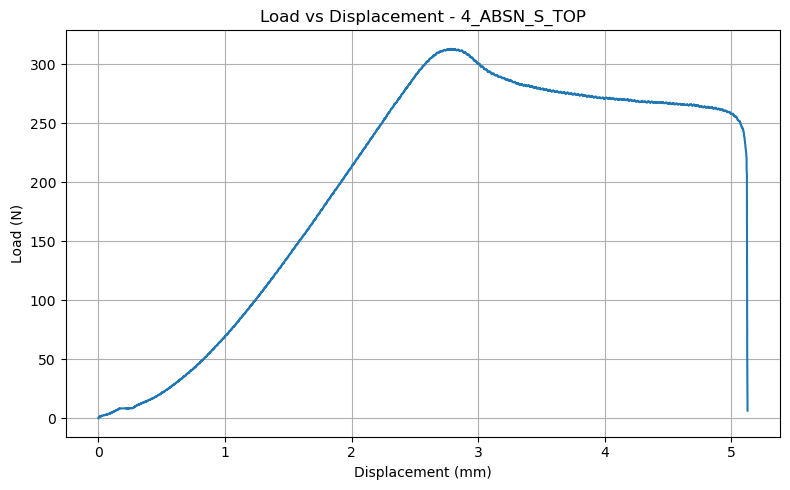

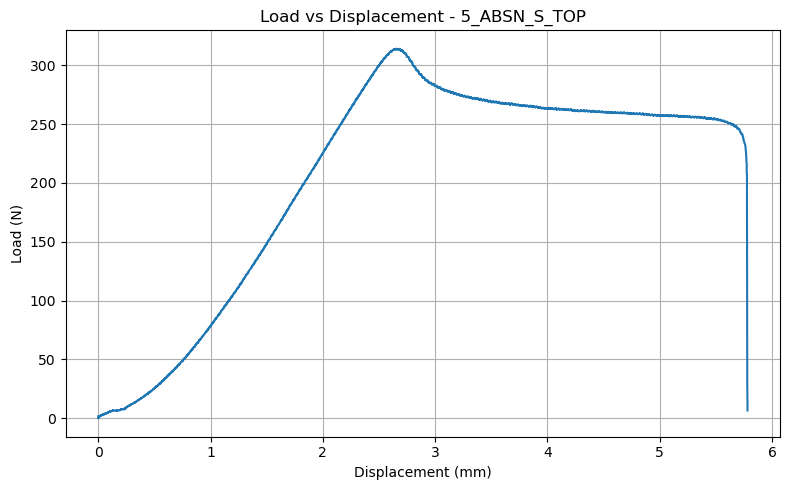

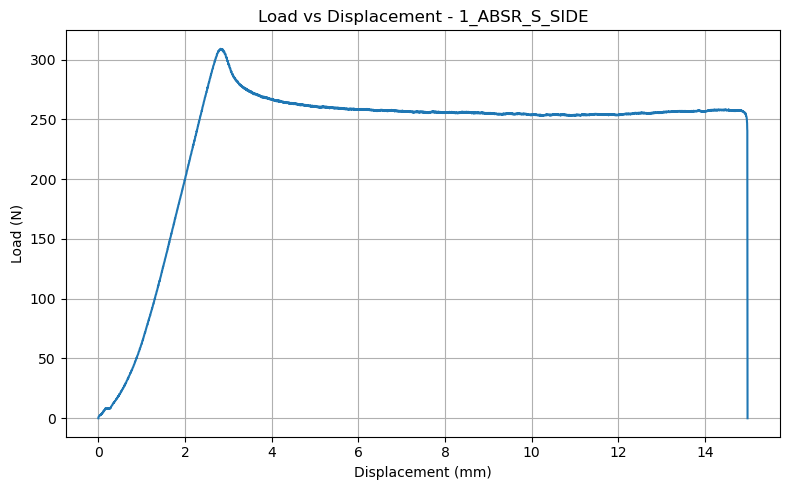

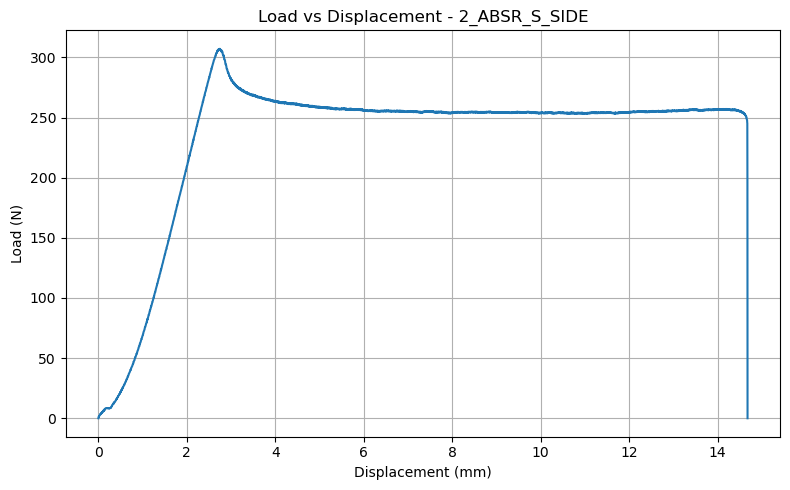

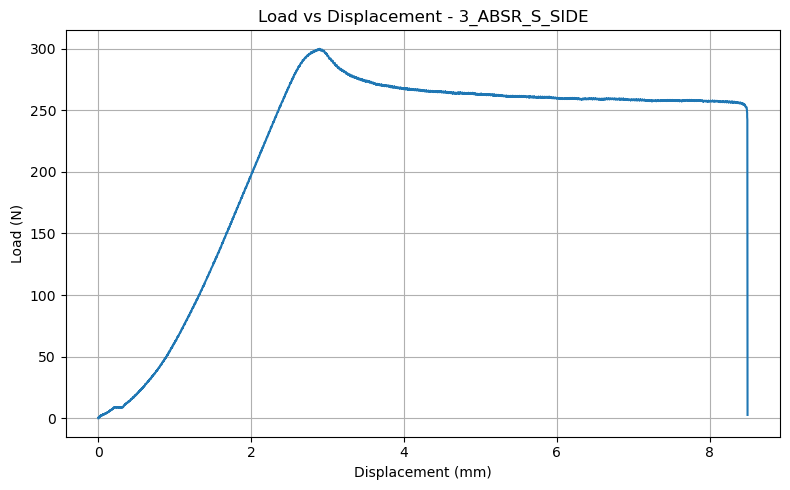

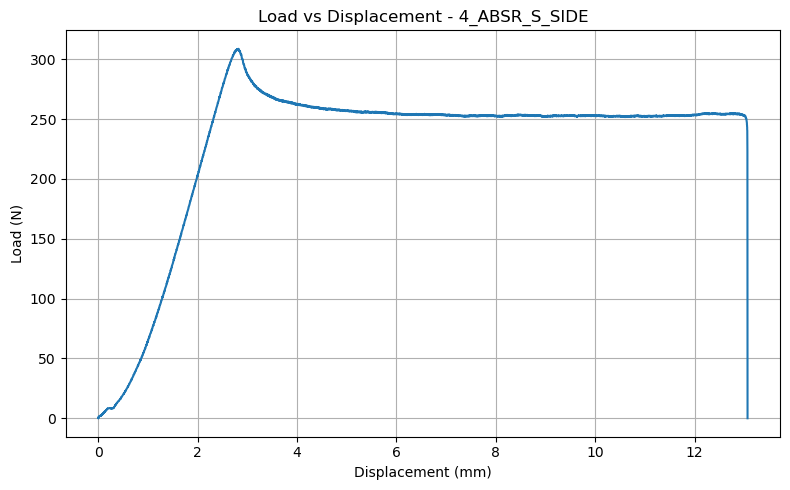

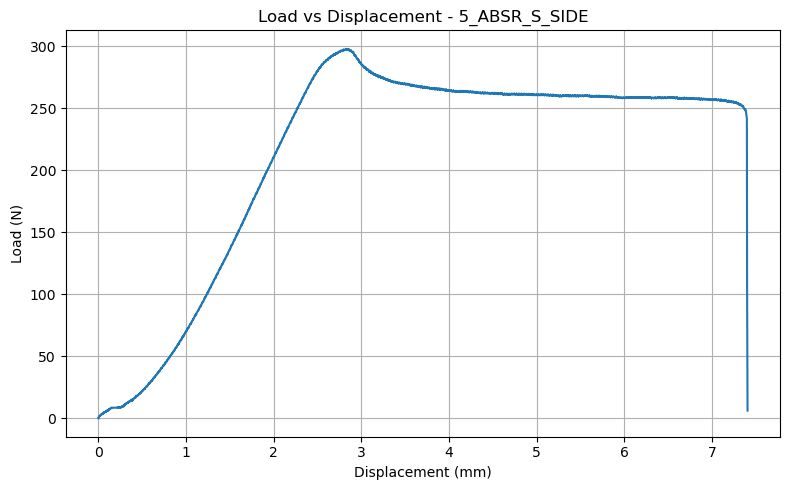

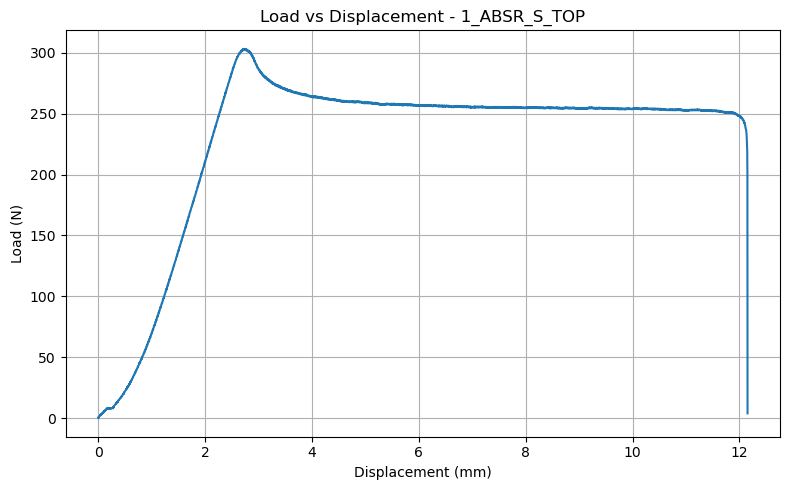

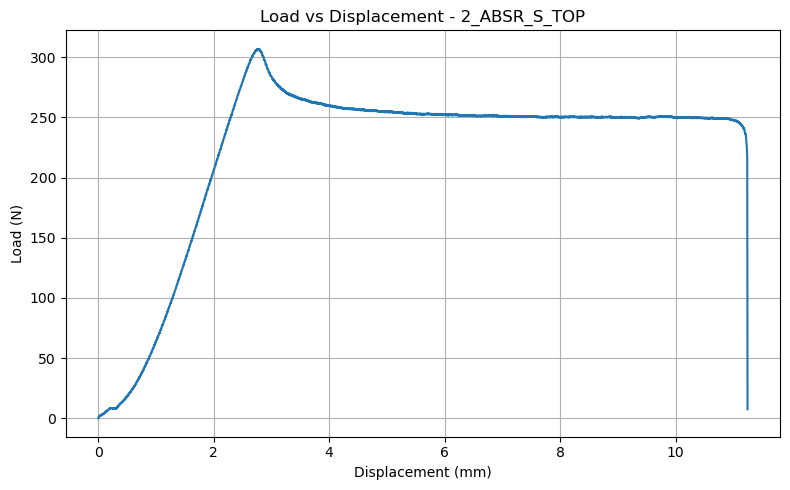

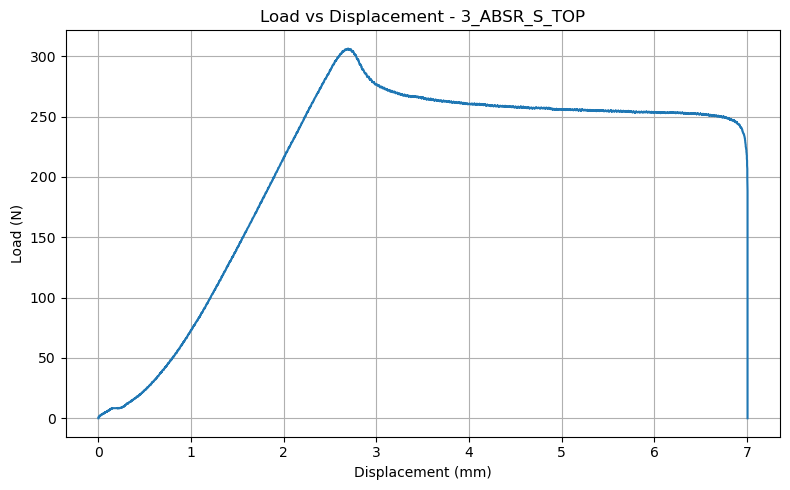

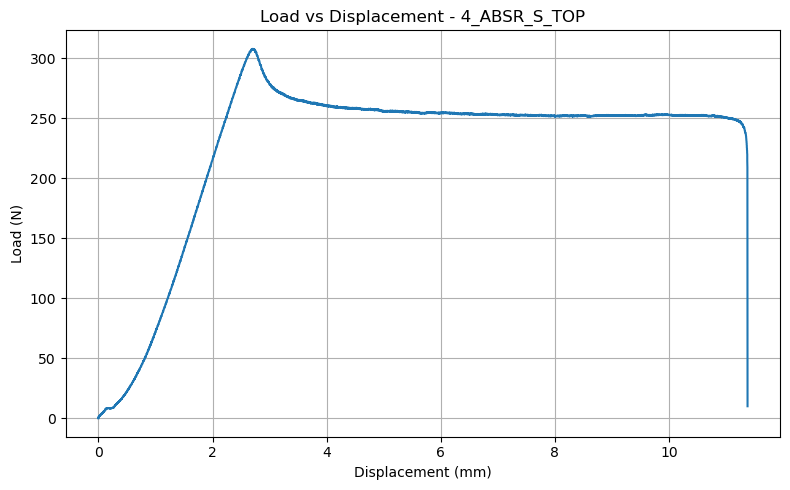

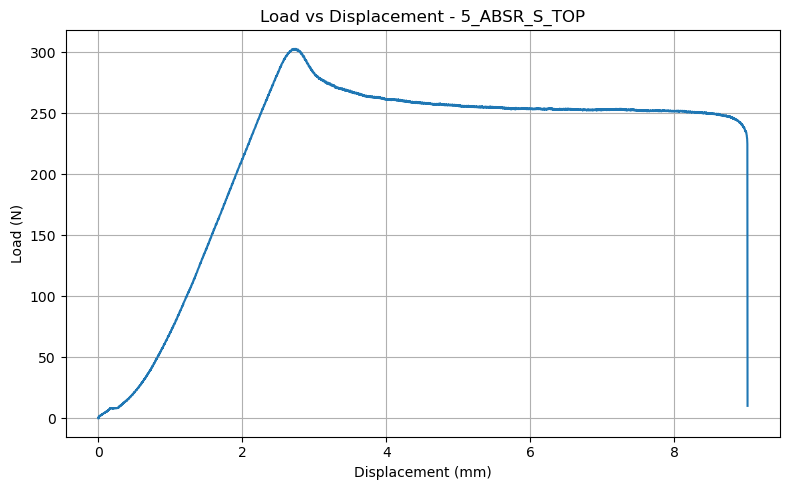

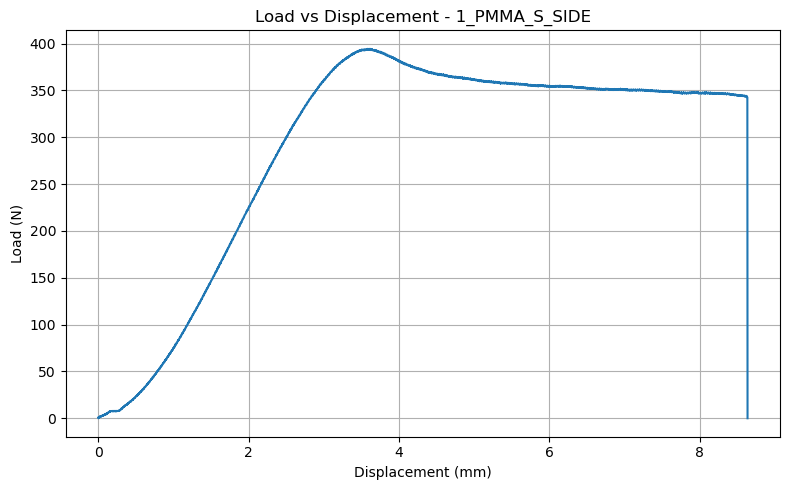

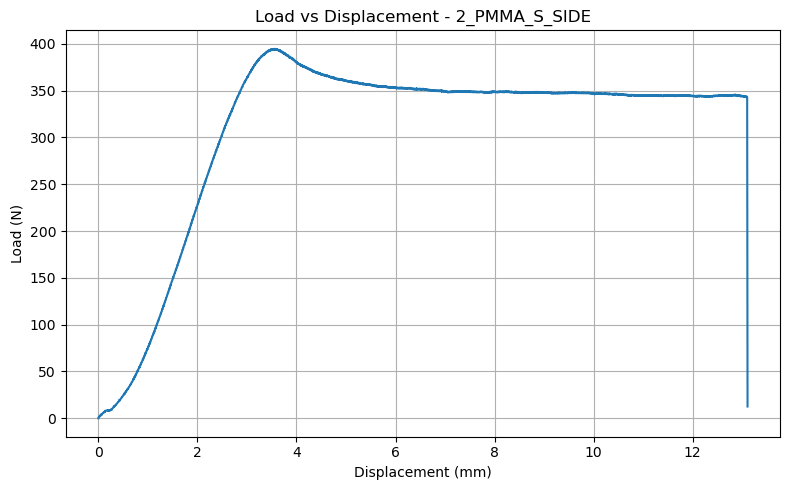

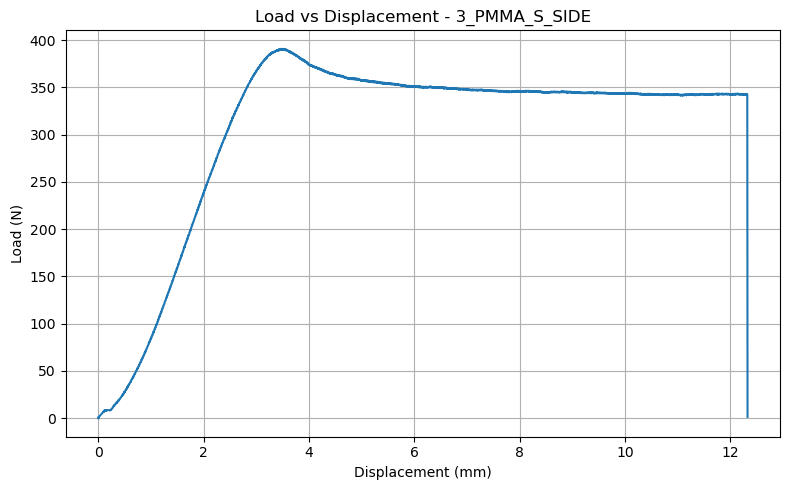

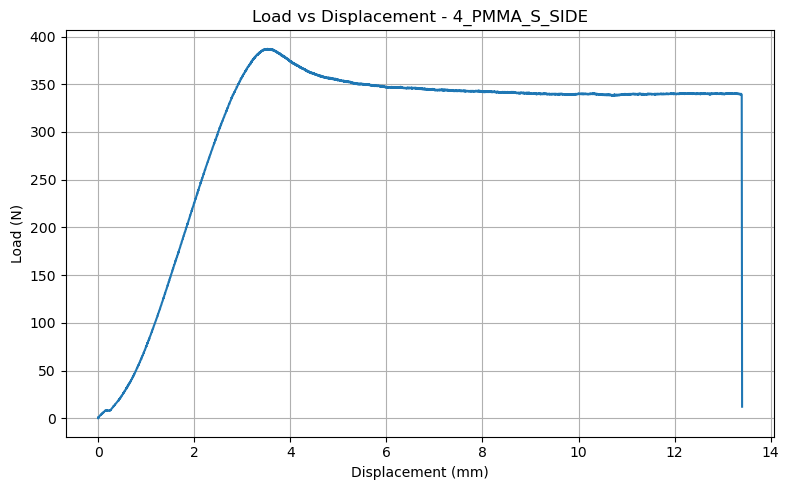

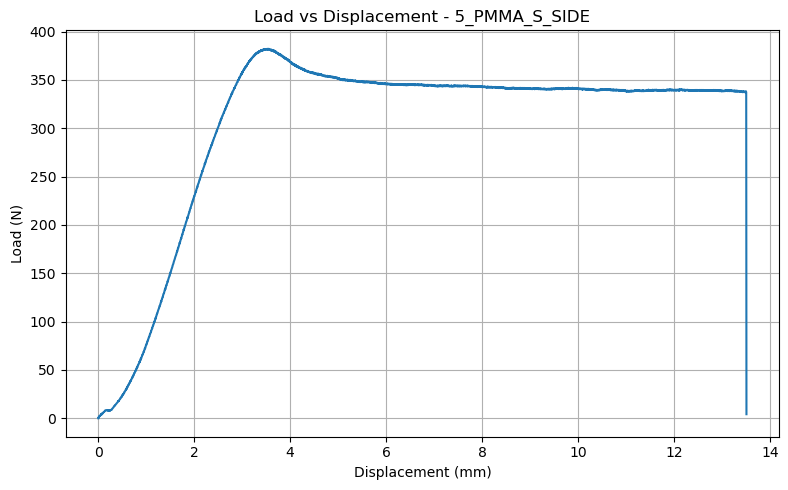

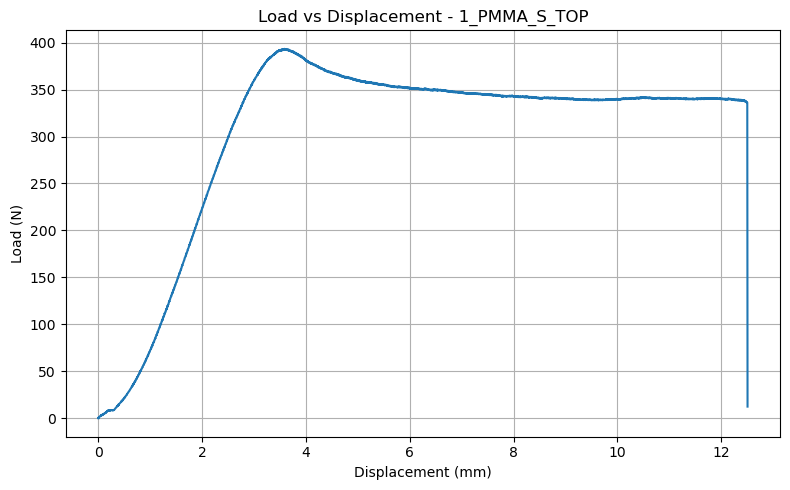

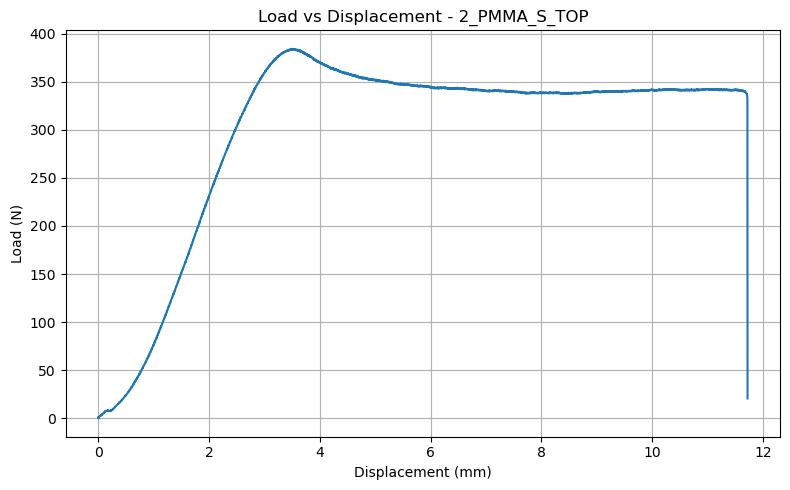

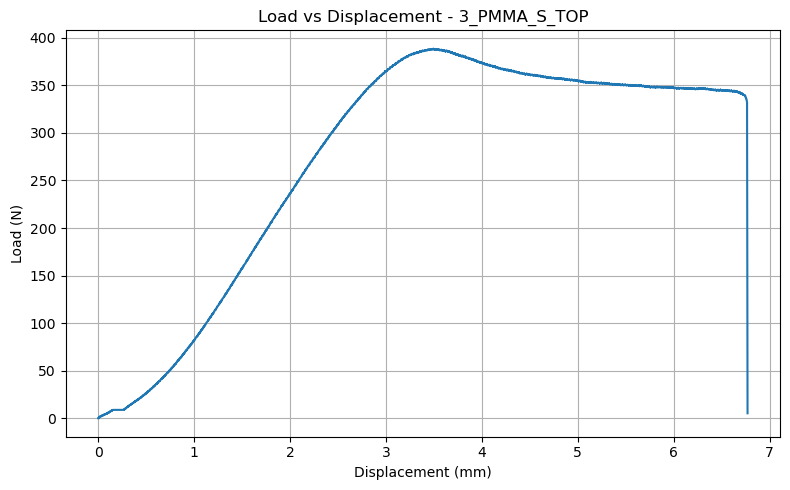

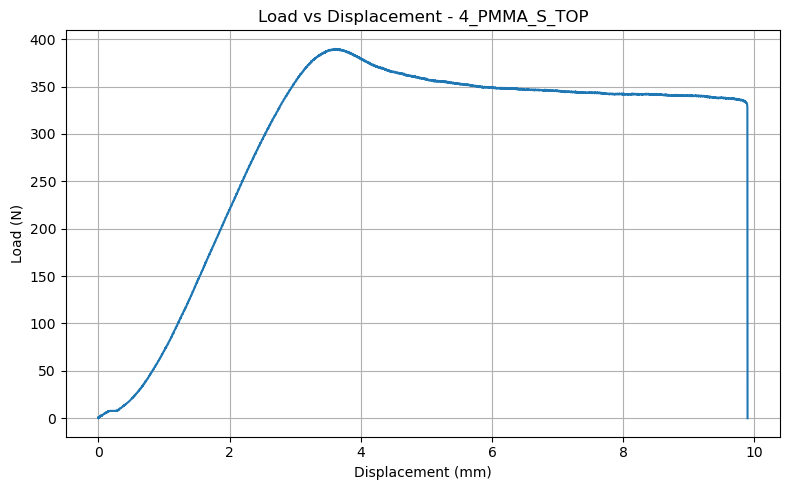

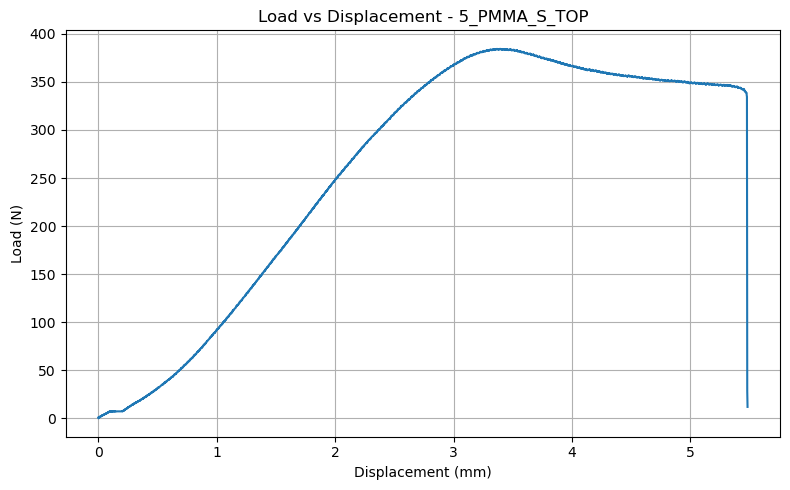

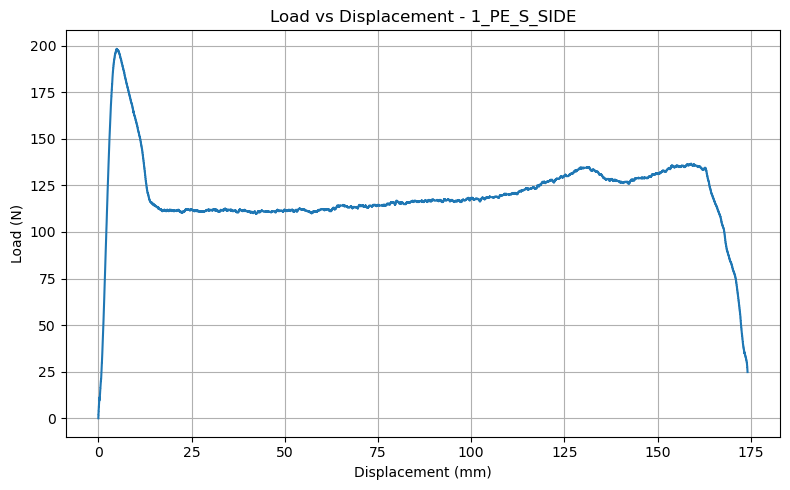

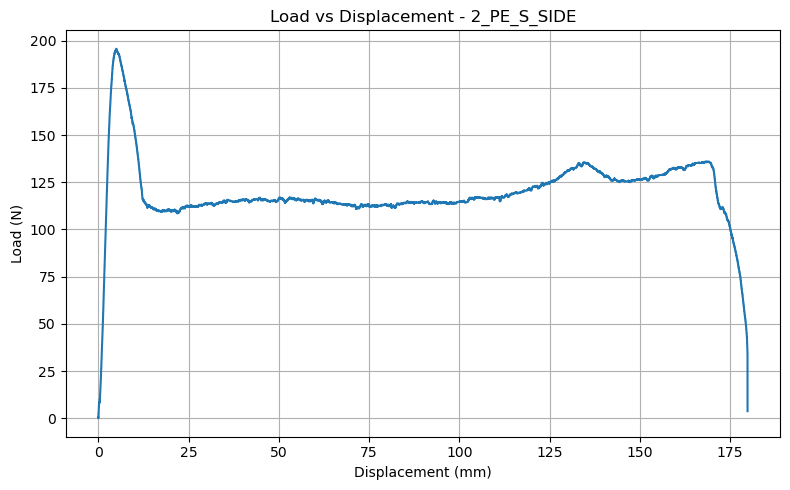

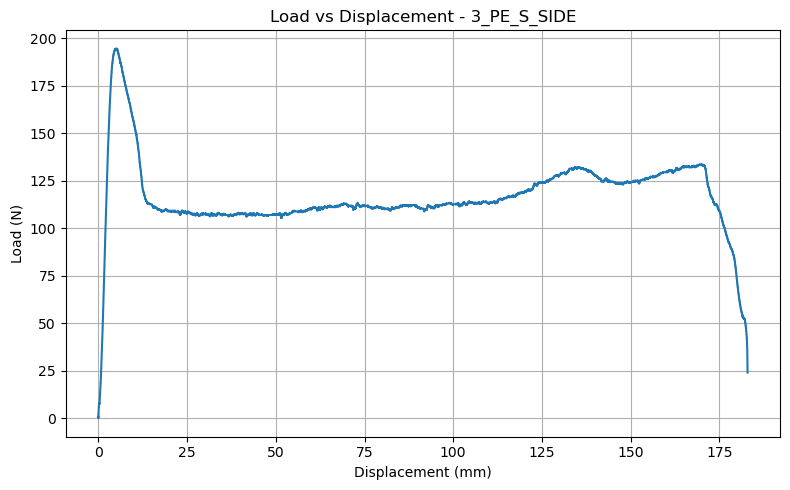

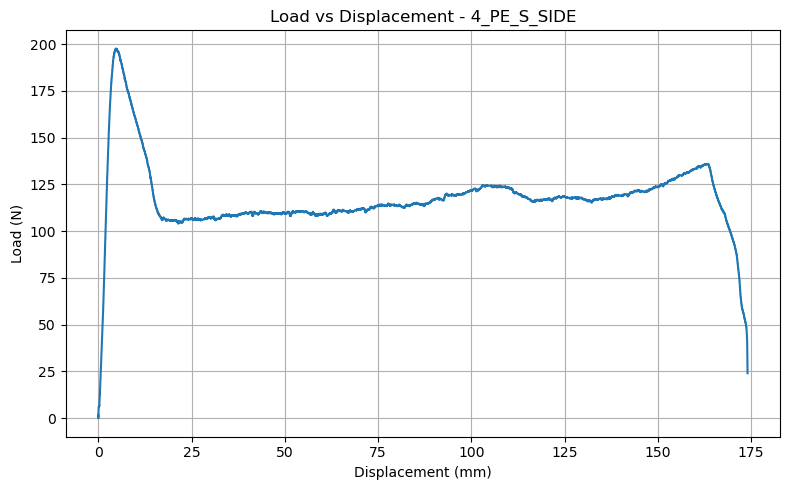

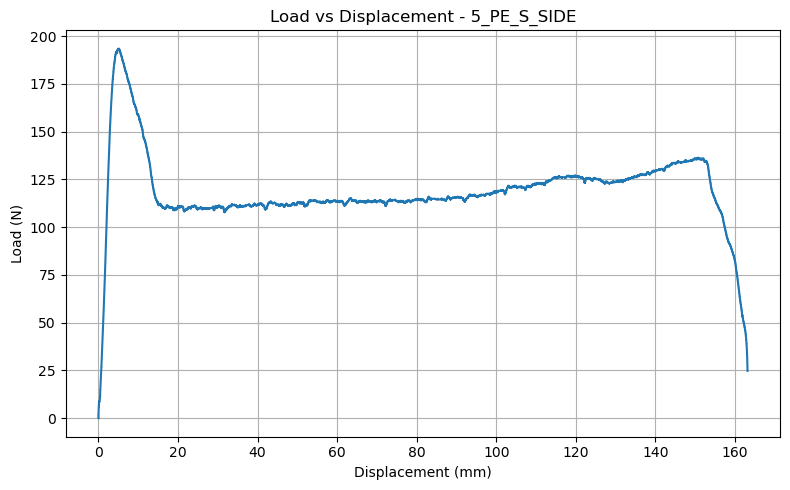

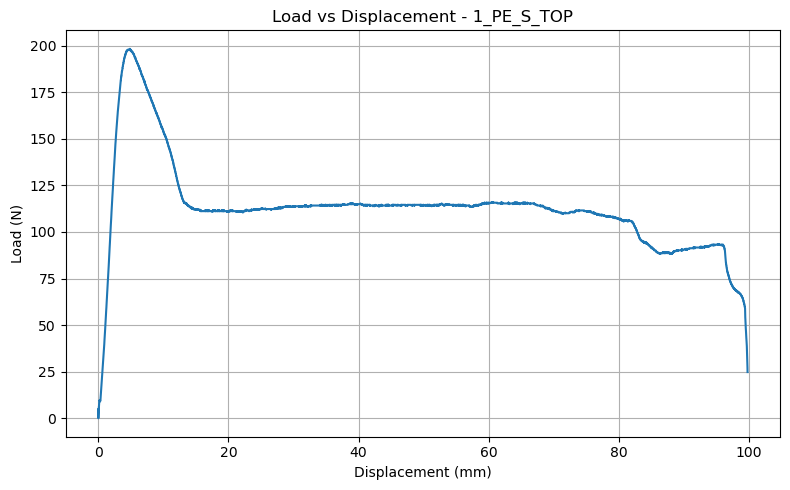

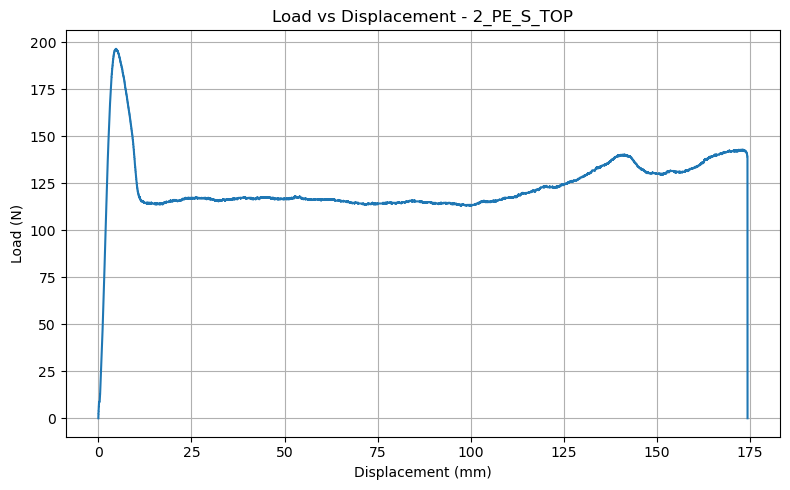

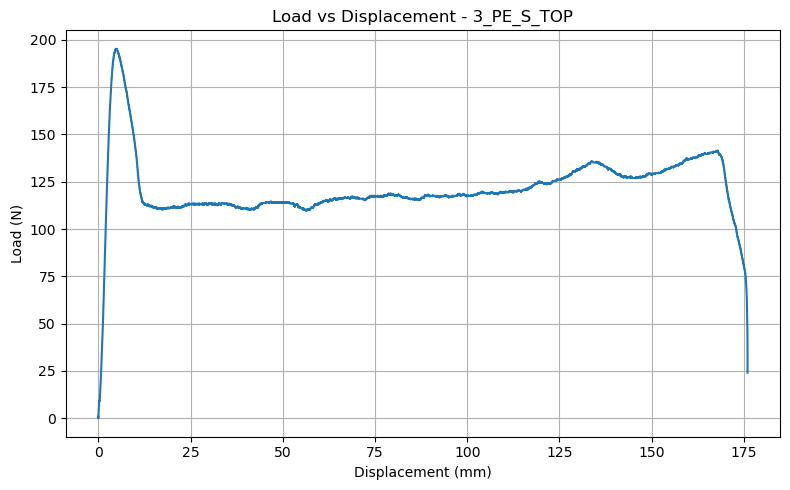

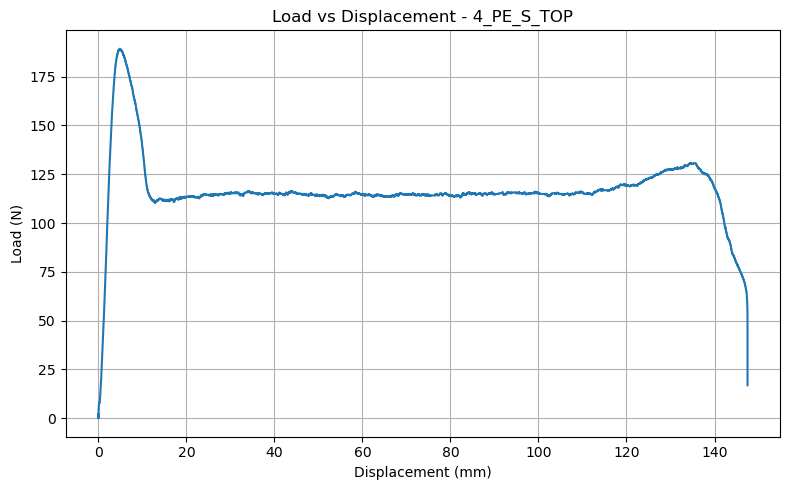

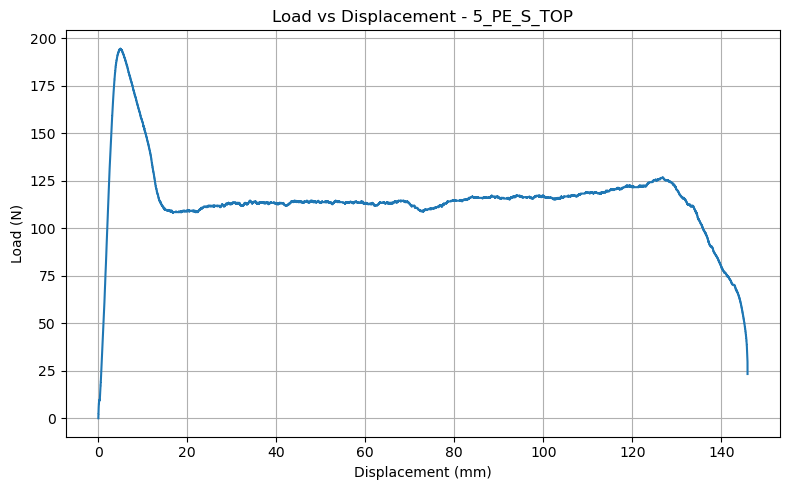

In [10]:
#Create plot for each sample
def plot_samples_individual(df_material, save=False):
    """
    For each material in the list, plot 5 corresponding samples individually.

    Parameters:
    - df_material: list of material identifiers like "abs_f", "pmma_s_top", etc.
    - save: whether to save each plot as a PNG
    """
    for material in df_material:
        var_name = f"{material}"
        try:
            df = globals()[var_name]
        except KeyError:
            print(f"Warning: {var_name} not found, skipping.")
            continue

        # Clean column names
        col_names = [col.strip().lower() for col in df.columns]

        try:
            load_idx = col_names.index("load")
            disp_idx = col_names.index("displacement")
        except ValueError as e:
            print(f"Error: {var_name} missing required columns. Skipping.")
            continue

        # Extract and clean data
        data = df.iloc[:, [disp_idx, load_idx]].astype(float)
        data.columns = ["Displacement", "Load"]

        # Plotting
        plt.figure(figsize=(8, 5))
        plt.plot(data["Displacement"], data["Load"])
        plt.xlabel("Displacement (mm)")
        plt.ylabel("Load (N)")
        plt.title(f"Load vs Displacement - {material[3:].upper()}")
        plt.grid(True)
        plt.tight_layout()

        if save:
            plt.savefig(f"plots/individual/{material}_single_sample.png")
        plt.show()

#Plot all samples individually
plot_samples_individual(df_names, save=True)

In [11]:
def plot_material_samples(material: str, save=False):
    """
    Plot Load vs Displacement for 5 samples of a given material on the same plot.

    Parameters:
    - material: String pattern used in variable names, e.g., "abs_f"
    - save: Whether to save the plot as a PNG
    """
    dfs = []
    df_names = []

    for i in range(1, 6):
        var_name = f"df_{i}_{material}"
        try:
            df = globals()[var_name]
            dfs.append(df)
            df_names.append(f"{material.upper()} {i}")
        except KeyError:
            raise KeyError(f"DataFrame '{var_name}' not found in global scope.")

    plt.figure(figsize=(10, 6))

    for df, name in zip(dfs, df_names):
        col_names = [col.strip().lower() for col in df.columns]

        try:
            load_idx = col_names.index("load")
            disp_idx = col_names.index("displacement")
        except ValueError as e:
            raise ValueError(f"Could not find 'Load' or 'Displacement' in columns: {df.columns}") from e

        data = df.iloc[:, [disp_idx, load_idx]].astype(float)
        data.columns = ["Displacement", "Load"]

        plt.plot(data["Displacement"], data["Load"], label=name)

    plt.xlabel("Displacement (mm)")
    plt.ylabel("Load (N)")
    plt.title(f"Load vs Displacement - Combined - {material.upper()}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if save:
        plt.savefig(f"plots/combined/{material}_all_samples.png")
    plt.show()


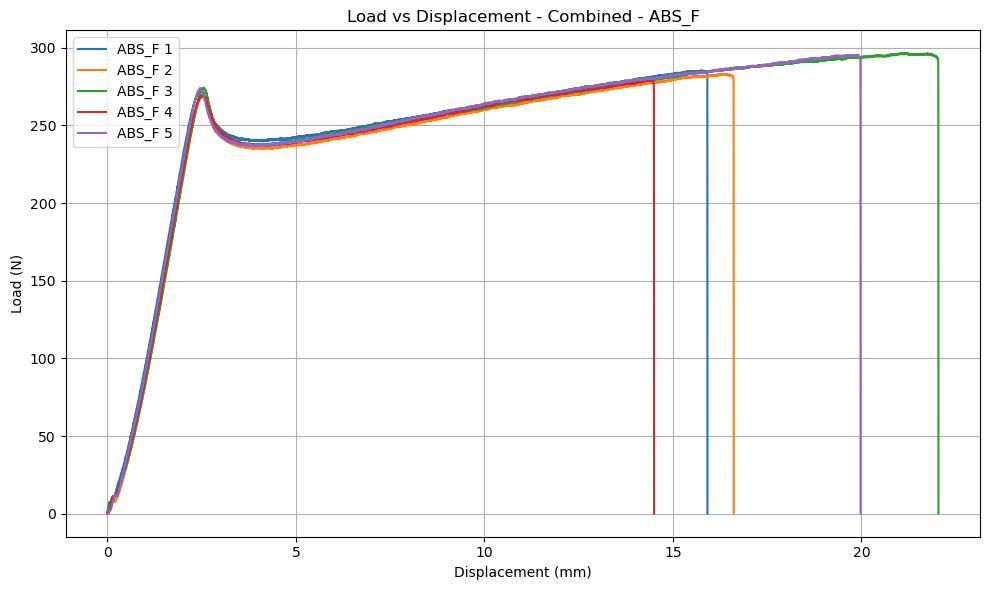

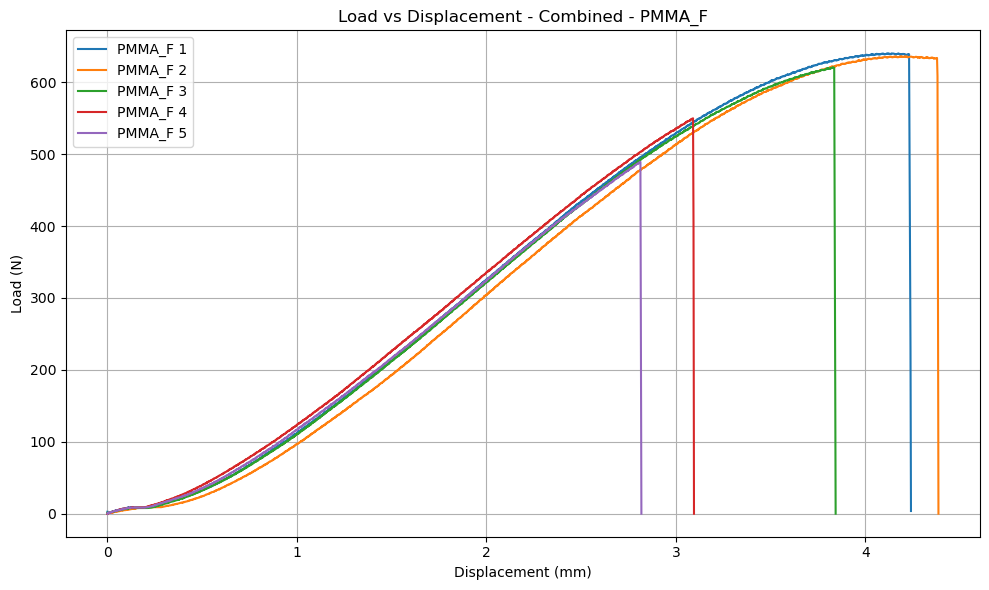

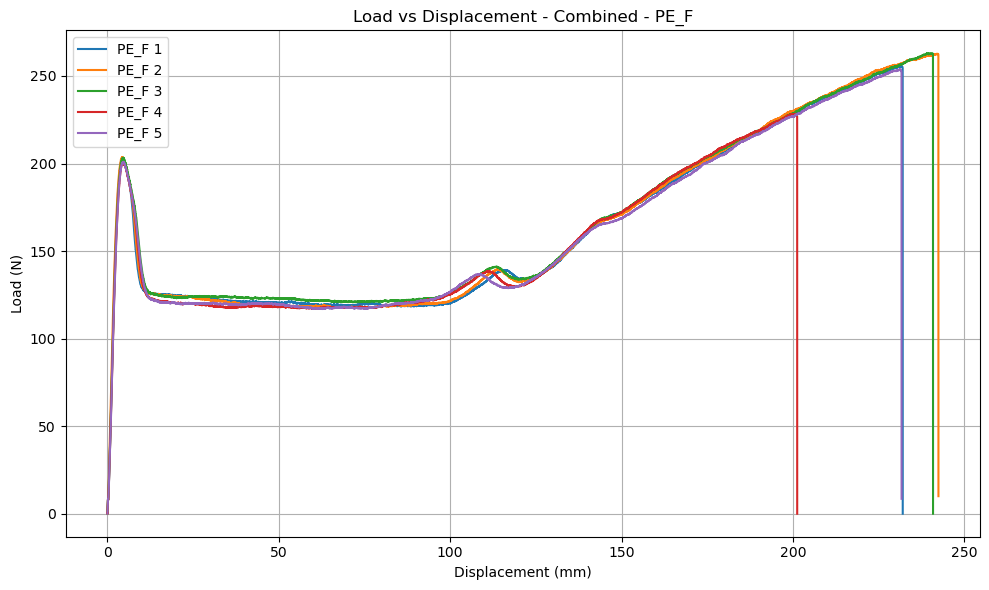

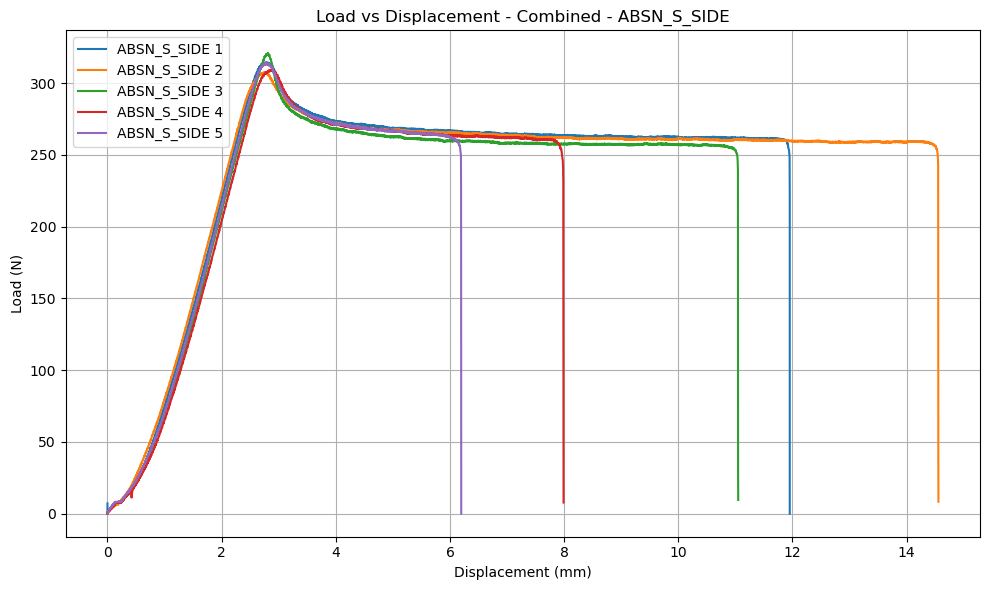

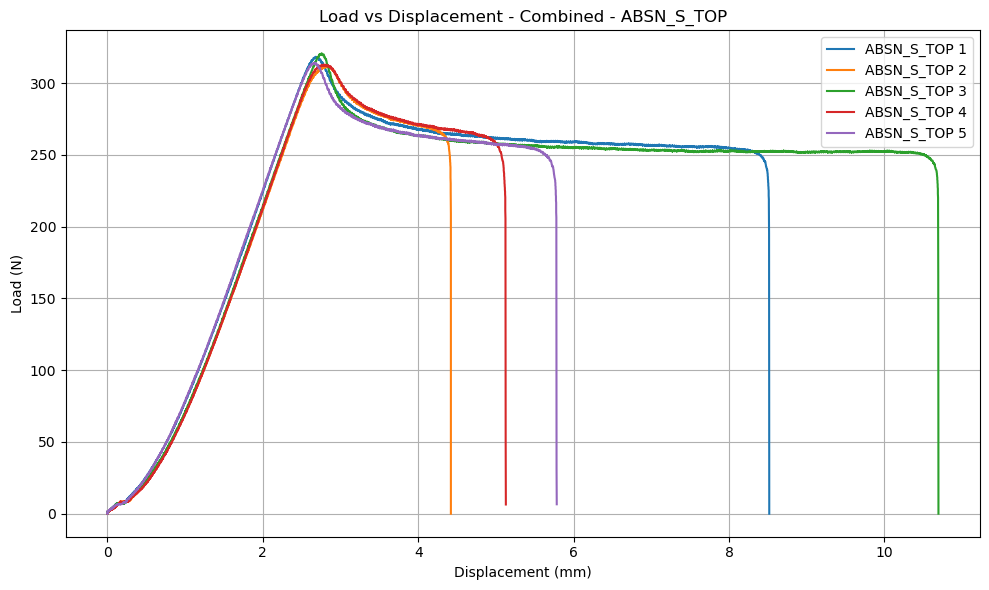

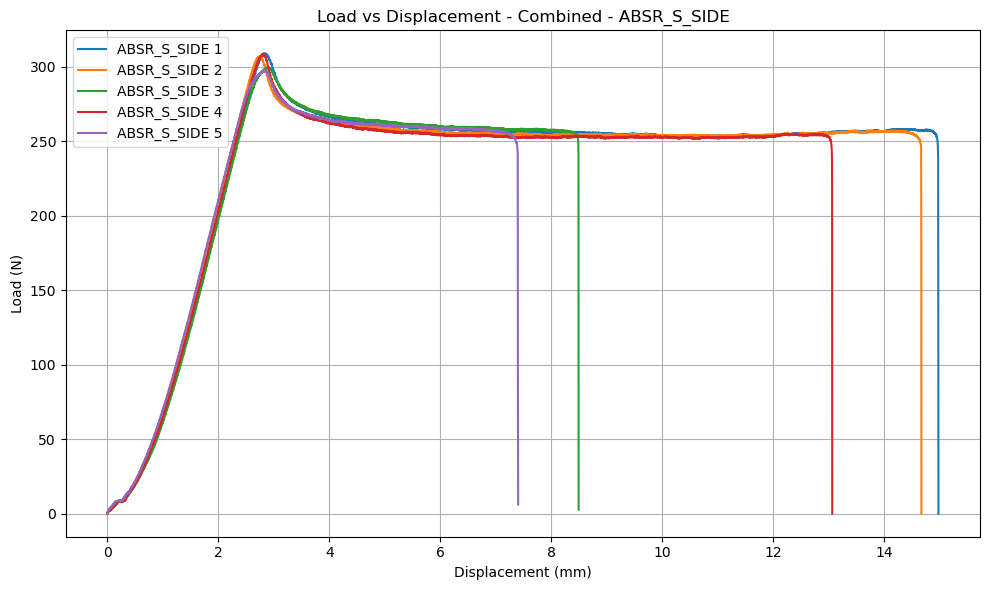

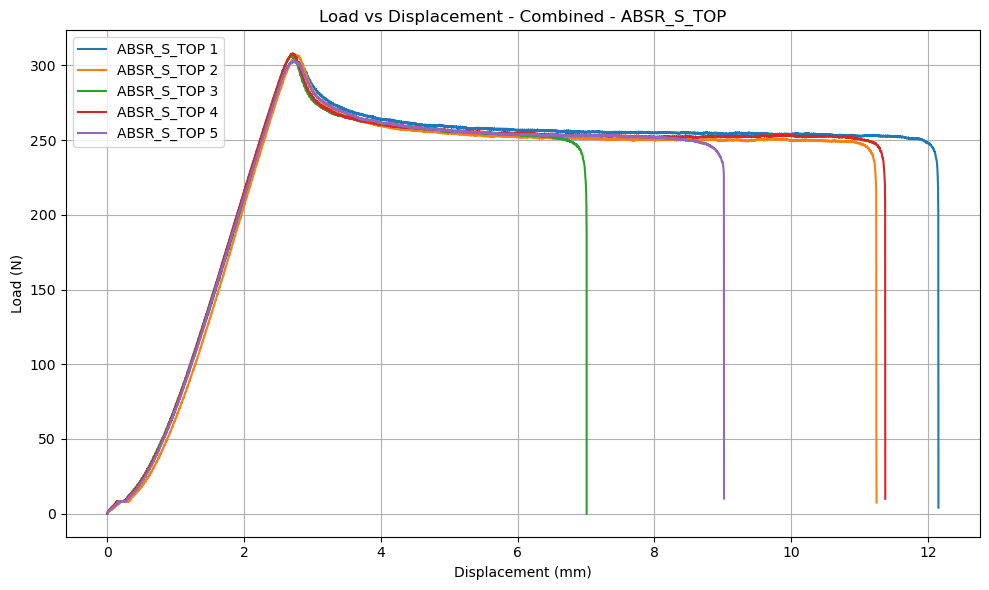

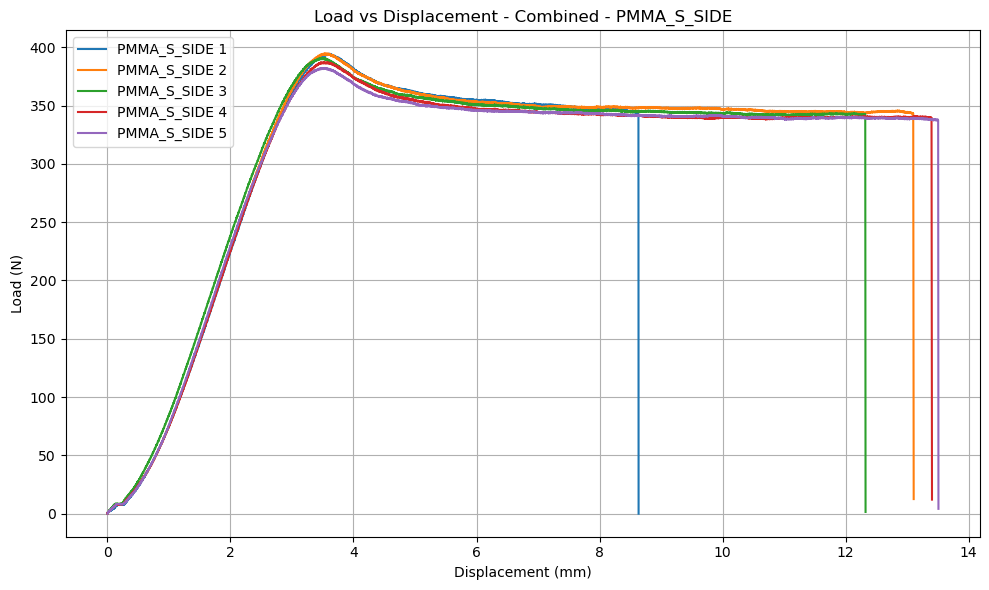

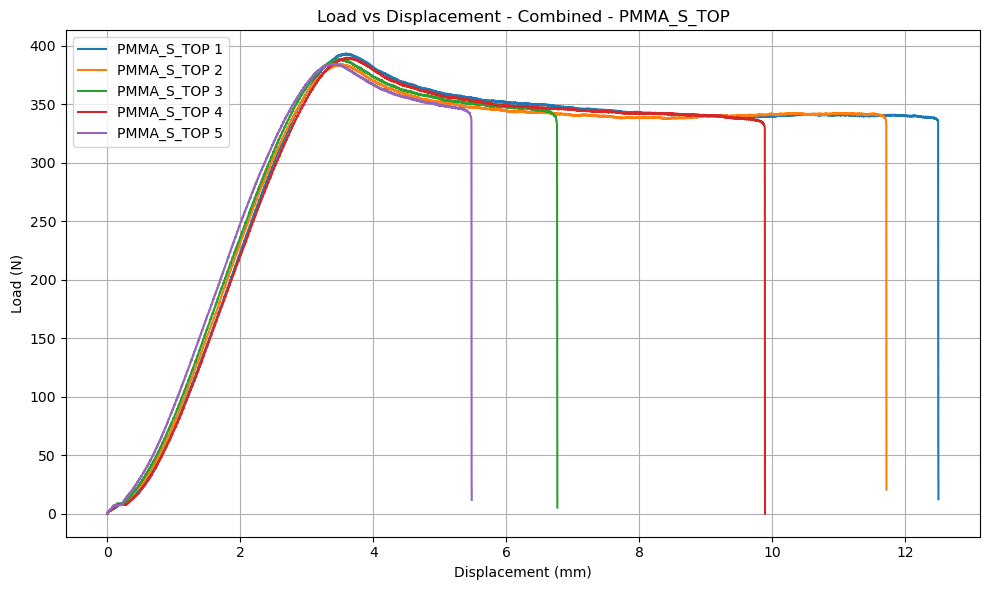

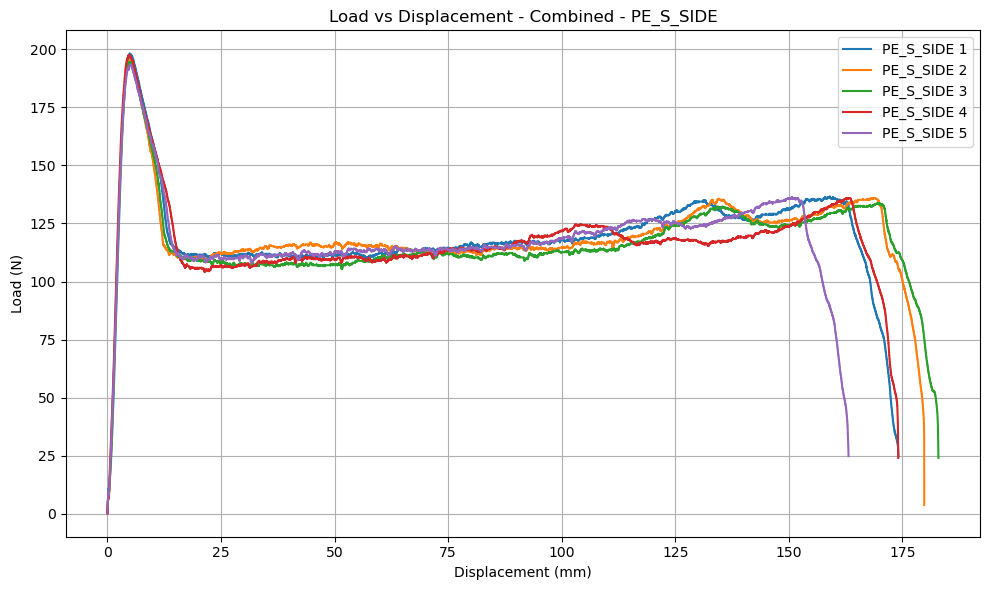

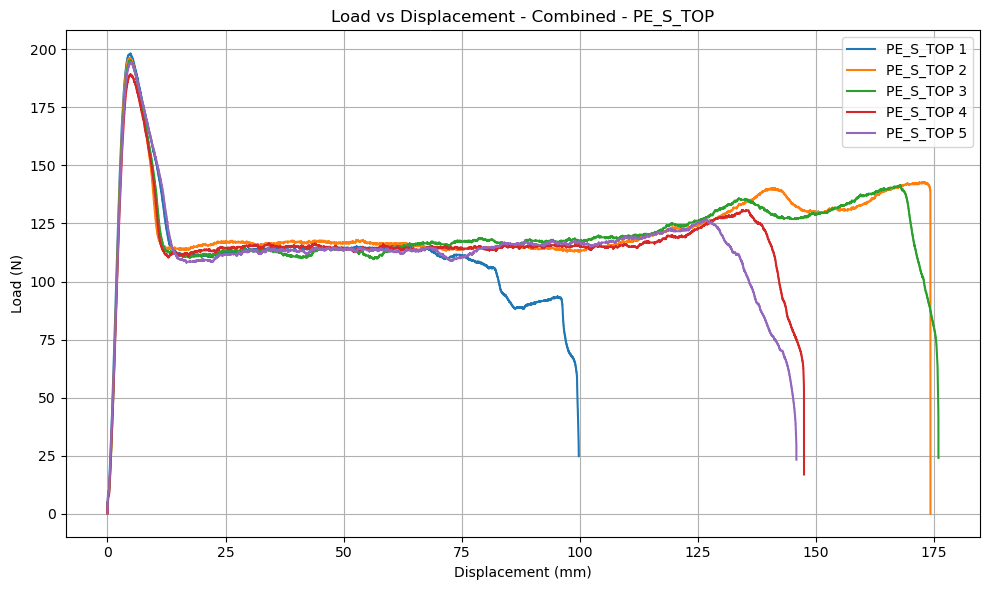

In [12]:
df_material = [
    "abs_f", "pmma_f", "pe_f",
    "absN_s_side", "absN_s_top",
    "absR_s_side", "absR_s_top",
    "pmma_s_side", "pmma_s_top",
    "pe_s_side", "pe_s_top"
]



for i in range(len(df_material)):
    plot_material_samples(df_material[i], save=True)
    #plot_samples_individual(df_material[i], save=True)
    plt.close()


In [13]:
#Find fracture point for each sample

from scipy.signal import savgol_filter

def find_fracture_info(dfs, df_names, strain_col='Displacement', stress_col='Load'):
    """
    Find fracture points for each DataFrame, limiting the search to the last 20% of data.

    Args:
    - dfs (list of pd.DataFrame): List of DataFrames with Load vs Displacement data.
    - df_names (list of str): List of names corresponding to each DataFrame.
    - strain_col (str): Name of the displacement column (acts like strain).
    - stress_col (str): Name of the load column (acts like stress).

    Returns:
    - results (list of dict): Each dict contains:
        'name'            : Name of the DataFrame,
        'fracture_index'  : Index where fracture begins,
        'fracture_strain' : Displacement at fracture start,
        'fracture_stress' : Load at fracture start.
    """
    results = []

    for df, name in zip(dfs, df_names):
        stress_raw = df[stress_col].values
        strain = df[strain_col].values
        n_points = len(df)

        # Limit search to the last 20% of data
        start_idx = int(n_points * 0.8)

        # Slice the region of interest
        stress_section = stress_raw[start_idx:]
        strain_section = strain[start_idx:]

        # Smooth the stress in the section
        if len(stress_section) >= 11:  # ensure window size is valid
            stress_smooth = savgol_filter(stress_section, window_length=11, polyorder=3)
        else:
            stress_smooth = stress_section  # skip smoothing if too short

        # Compute gradient
        gradient = np.gradient(stress_smooth)

        # Peak stress in this section
        peak_index_local = np.argmax(stress_smooth)
        peak_stress = stress_smooth[peak_index_local]

        # Define 30% drop threshold
        drop_threshold = 0.9 * peak_stress

        # Search for first drop below threshold after the peak
        post_peak = stress_smooth[peak_index_local:]
        drop_indices = np.where(post_peak < drop_threshold)[0]

        if len(drop_indices) == 0:
            fracture_index_local = len(stress_section) - 1
        else:
            first_drop_index_local = peak_index_local + drop_indices[0]

            # Backtrack to where the slope turns consistently negative
            for i in range(first_drop_index_local, peak_index_local, -1):
                if gradient[i] > 0:  # slope increasing again
                    fracture_index_local = i + 1
                    break
            else:
                fracture_index_local = peak_index_local

        # Convert local index to original DataFrame index
        fracture_index = start_idx + fracture_index_local

        results.append({
            'name': name,
            'fracture_index': fracture_index,
            'fracture_strain': strain[fracture_index],
            'fracture_stress': stress_raw[fracture_index]
        })

    return results



fracture_results=find_fracture_info(df_list, df_names)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27188\2658329523.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='material', y='fracture_strain', palette='Set2')


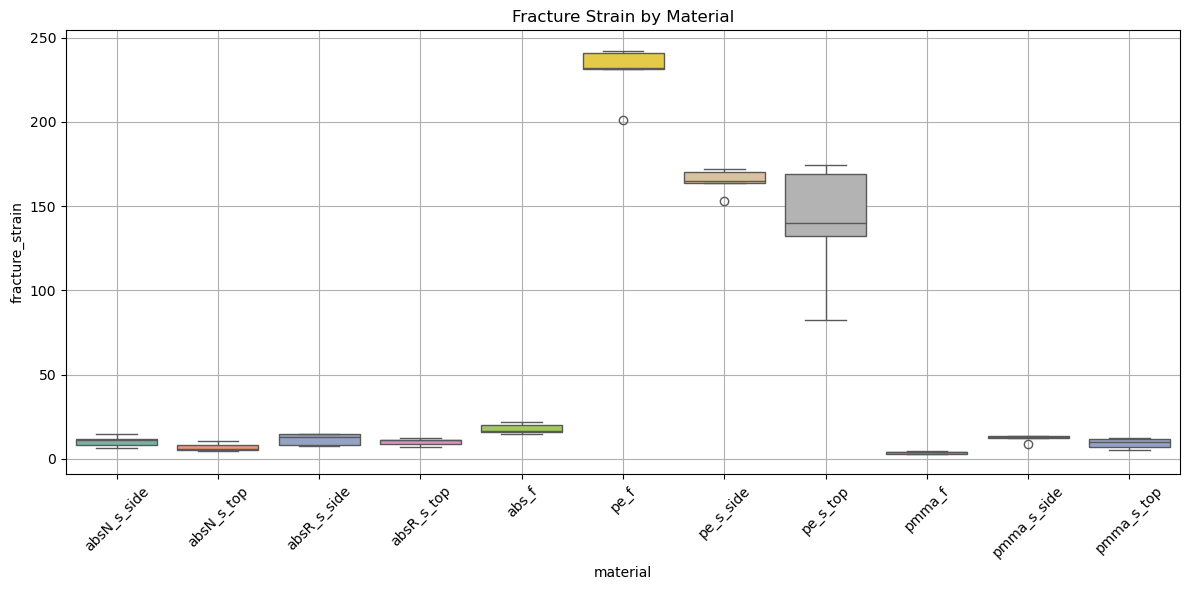

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27188\2658329523.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='material', y='fracture_stress', palette='Set3')


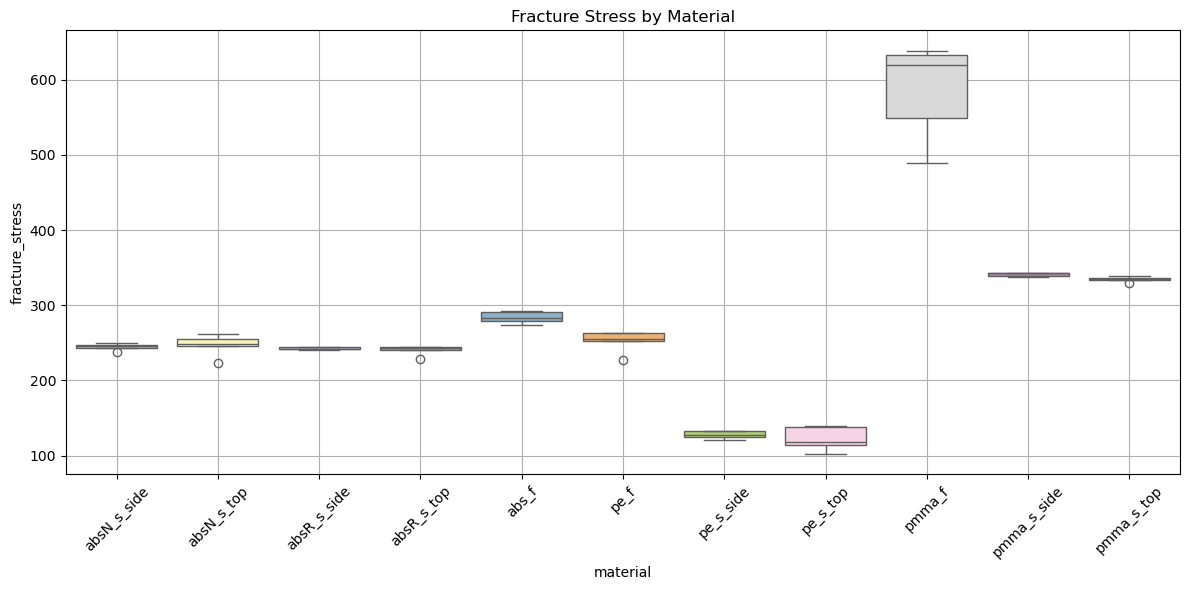

In [14]:
#Generate combined boxplot for fracture strain and stress

# Expand to match the results length (5 samples per material)
material_expanded = [mat for mat in df_material for _ in range(5)]

# Sanity check
assert len(material_expanded) == len(fracture_results), "Mismatch in material and results length."

# Convert to DataFrame and assign materials
df = pd.DataFrame(fracture_results)
df['material'] = material_expanded

# Sort DataFrame alphabetically by material
df = df.sort_values(by='material')

# Fracture strain boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='material', y='fracture_strain', palette='Set2')
plt.xticks(rotation=45)
plt.title("Fracture Strain by Material")
plt.grid(True)
plt.tight_layout()
plt.show()

# Fracture stress boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='material', y='fracture_stress', palette='Set3')
plt.xticks(rotation=45)
plt.title("Fracture Stress by Material")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27188\1280560883.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=abs_materials, x='material', y='fracture_strain', palette='Blues')


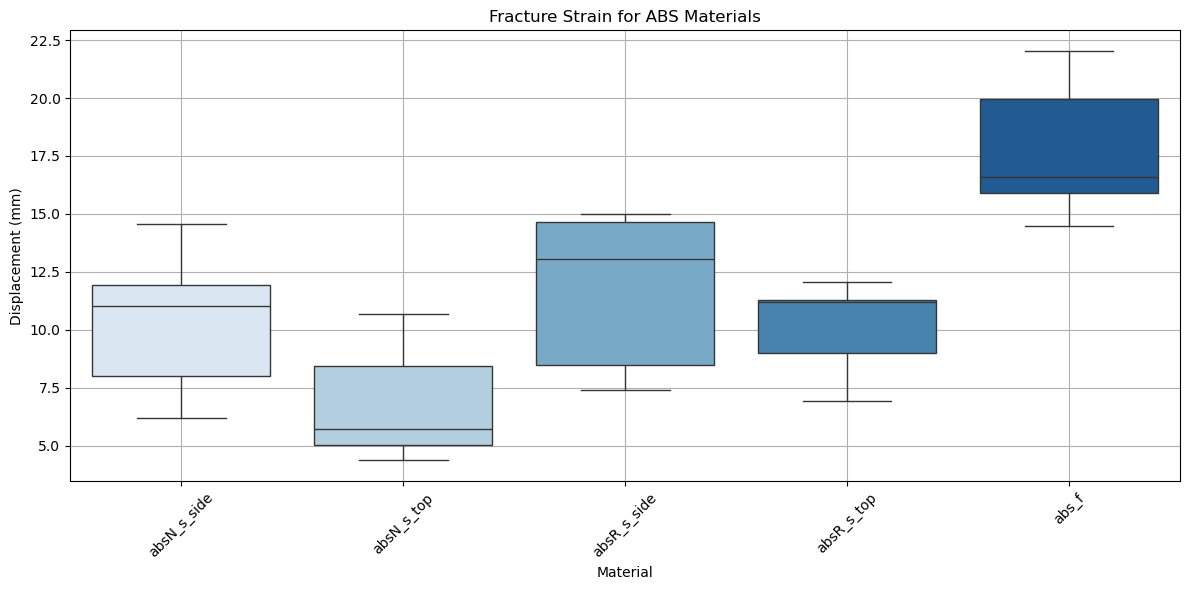

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27188\1280560883.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pe_materials, x='material', y='fracture_strain', palette='Greens')


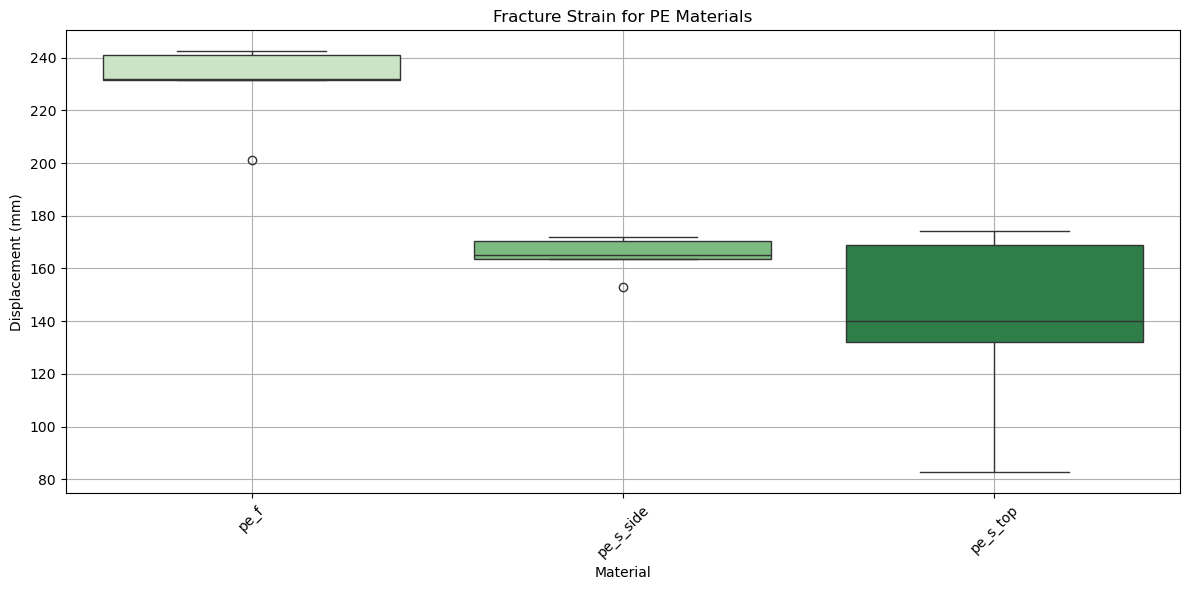

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27188\1280560883.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pmma_materials, x='material', y='fracture_strain', palette='Oranges')


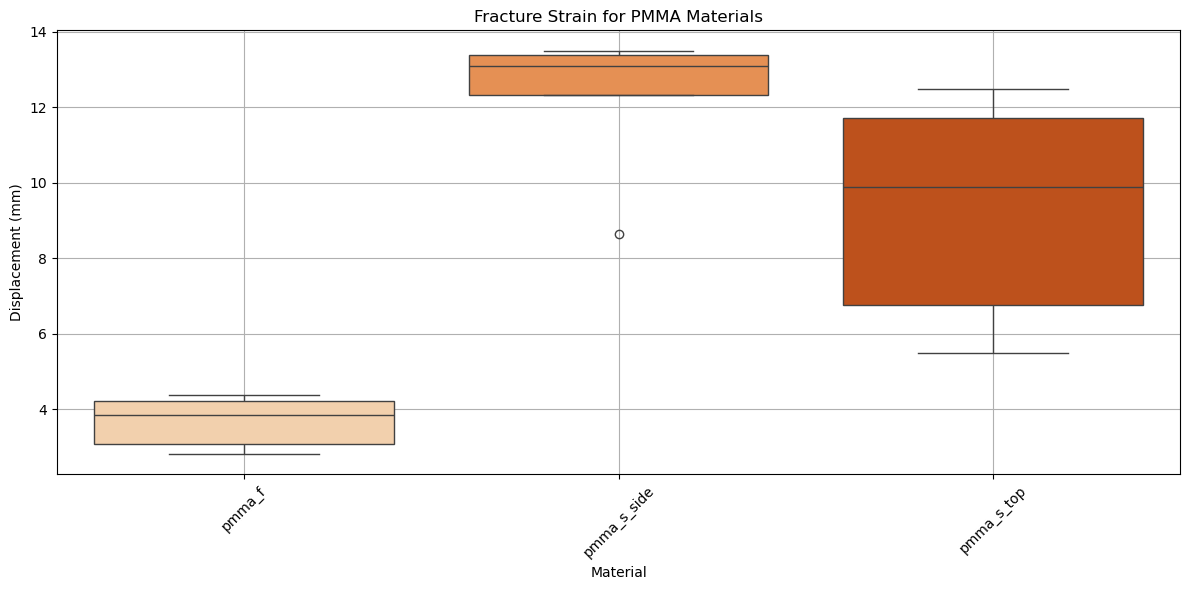

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27188\1280560883.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=abs_materials, x='material', y='fracture_stress', palette='Blues')


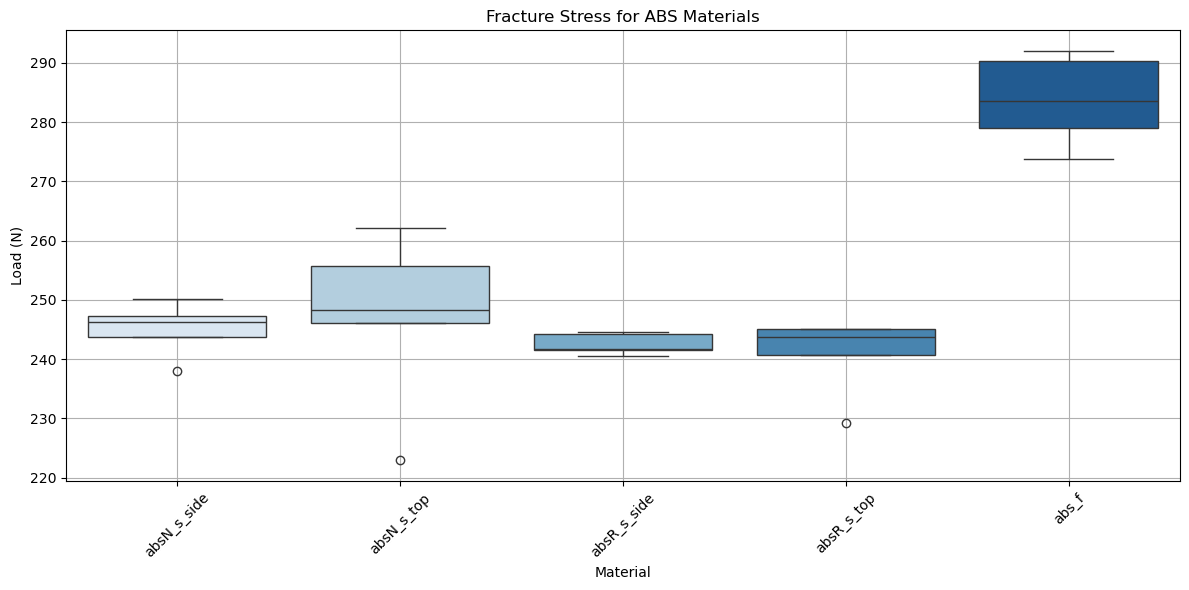

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27188\1280560883.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pe_materials, x='material', y='fracture_stress', palette='Greens')


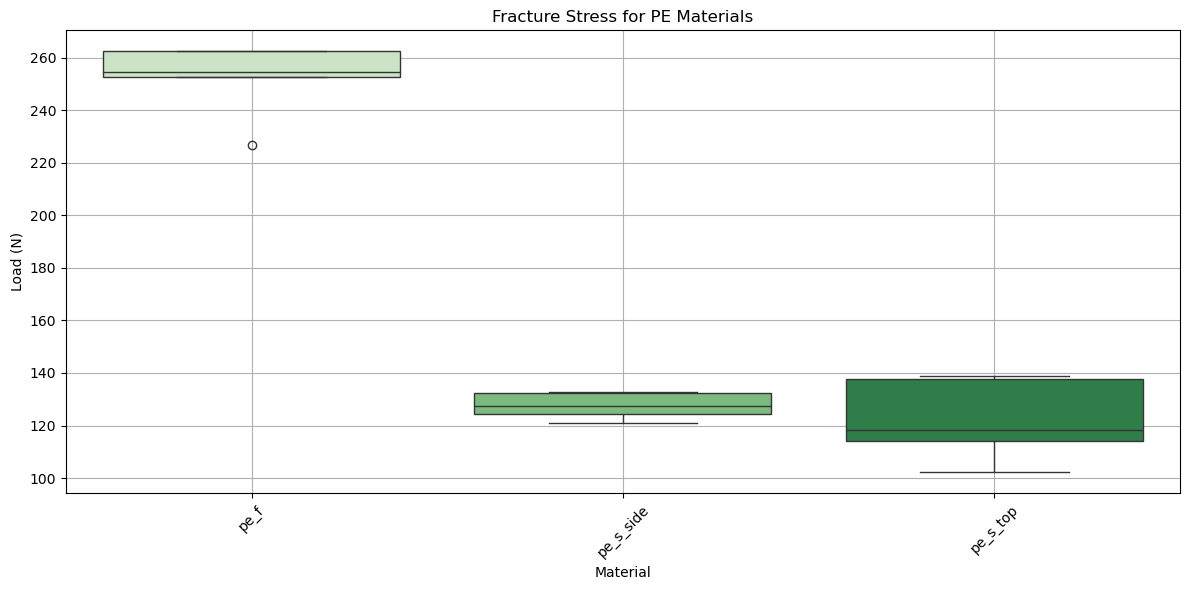

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27188\1280560883.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pmma_materials, x='material', y='fracture_stress', palette='Oranges')


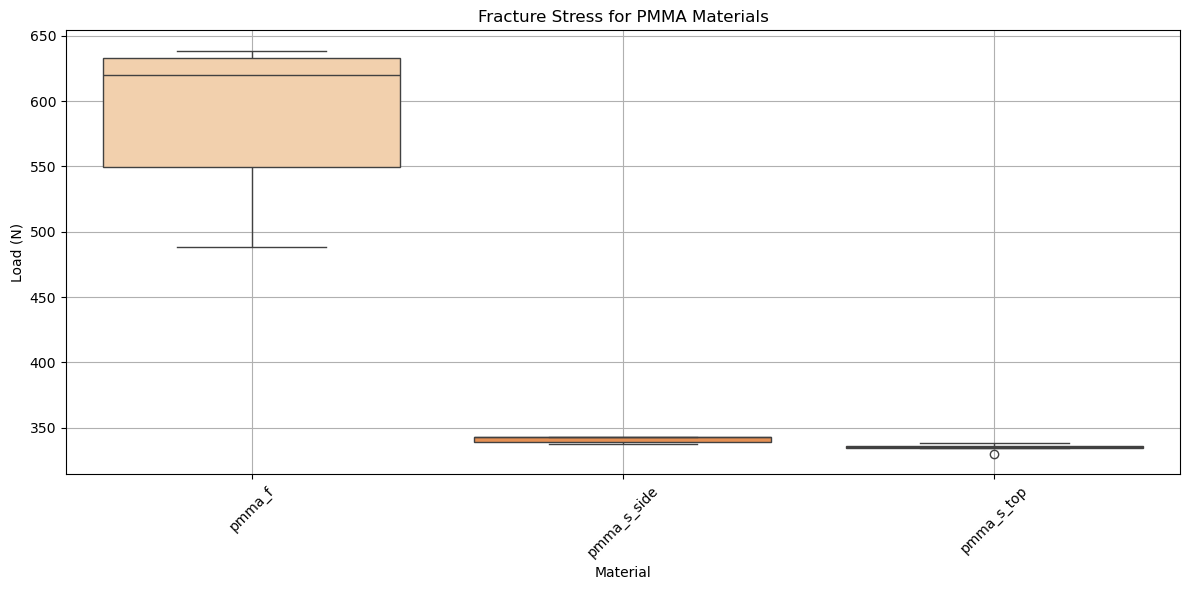

In [15]:
#Generate material specific boxplots for fracture strain and stress
# Group data by material prefix
abs_materials = df[df['material'].str.startswith('abs')]
pe_materials = df[df['material'].str.startswith('pe')]
pmma_materials = df[df['material'].str.startswith('pmma')]


import seaborn as sns
import matplotlib.pyplot as plt

# Fracture strain for "abs" materials
plt.figure(figsize=(12, 6))
sns.boxplot(data=abs_materials, x='material', y='fracture_strain', palette='Blues')
plt.xticks(rotation=45)
plt.title("Fracture Strain for ABS Materials")
plt.ylabel("Displacement (mm)")
plt.xlabel("Material")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/boxplots/boxplot_abs_fracture_strain.png")
plt.show()

# Fracture strain for "pe" materials
plt.figure(figsize=(12, 6))
sns.boxplot(data=pe_materials, x='material', y='fracture_strain', palette='Greens')
plt.xticks(rotation=45)
plt.title("Fracture Strain for PE Materials")
plt.ylabel("Displacement (mm)")
plt.xlabel("Material")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/boxplots/boxplot_pe_fracture_strain.png")
plt.show()

# Fracture strain for "pmma" materials
plt.figure(figsize=(12, 6))
sns.boxplot(data=pmma_materials, x='material', y='fracture_strain', palette='Oranges')
plt.xticks(rotation=45)
plt.title("Fracture Strain for PMMA Materials")
plt.ylabel("Displacement (mm)")
plt.xlabel("Material")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/boxplots/boxplot_pmma_fracture_strain.png")
plt.show()

# Fracture stress for "abs" materials
plt.figure(figsize=(12, 6))
sns.boxplot(data=abs_materials, x='material', y='fracture_stress', palette='Blues')
plt.xticks(rotation=45)
plt.title("Fracture Stress for ABS Materials")
plt.ylabel("Load (N)")
plt.xlabel("Material")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/boxplots/boxplot_abs_fracture_stress.png")
plt.show()

# Fracture stress for "pe" materials
plt.figure(figsize=(12, 6))
sns.boxplot(data=pe_materials, x='material', y='fracture_stress', palette='Greens')
plt.xticks(rotation=45)
plt.title("Fracture Stress for PE Materials")
plt.ylabel("Load (N)")
plt.xlabel("Material")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/boxplots/boxplot_pe_fracture_stress.png")
plt.show()

# Fracture stress for "pmma" materials
plt.figure(figsize=(12, 6))
sns.boxplot(data=pmma_materials, x='material', y='fracture_stress', palette='Oranges')
plt.xticks(rotation=45)
plt.title("Fracture Stress for PMMA Materials")
plt.ylabel("Load (N)")
plt.xlabel("Material")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/boxplots/boxplot_pmma_fracture_stress.png")
plt.show()


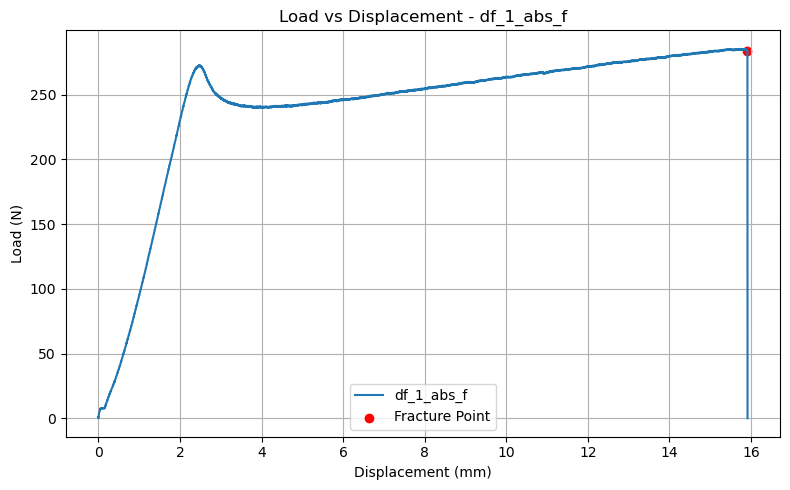

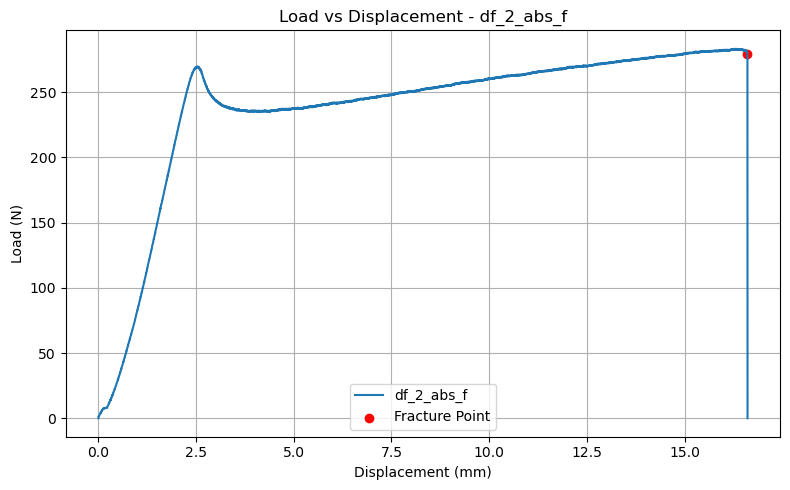

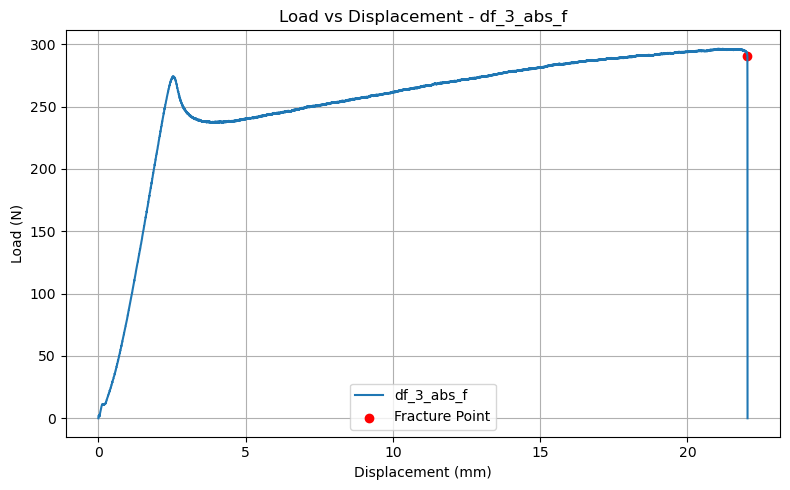

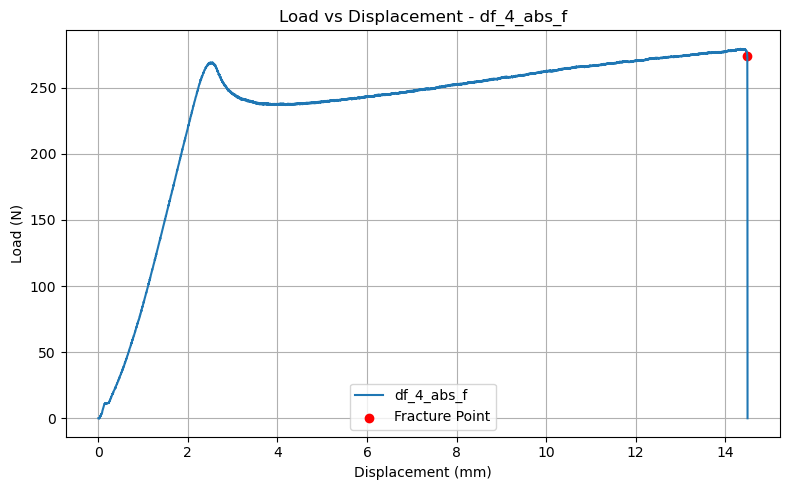

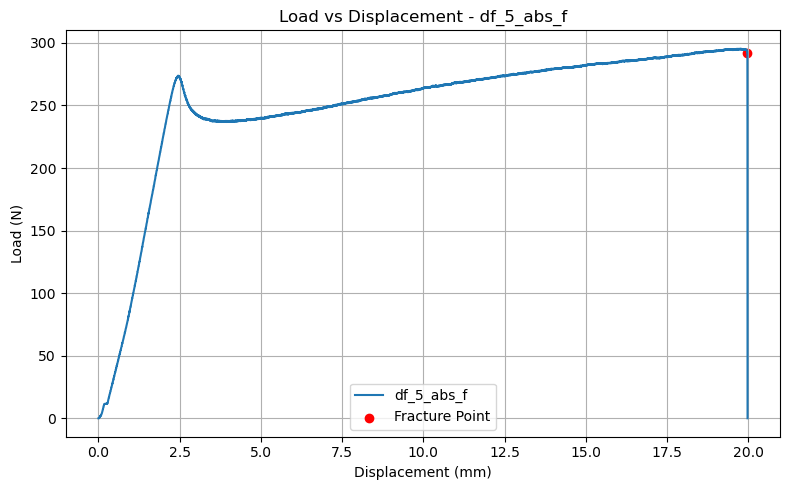

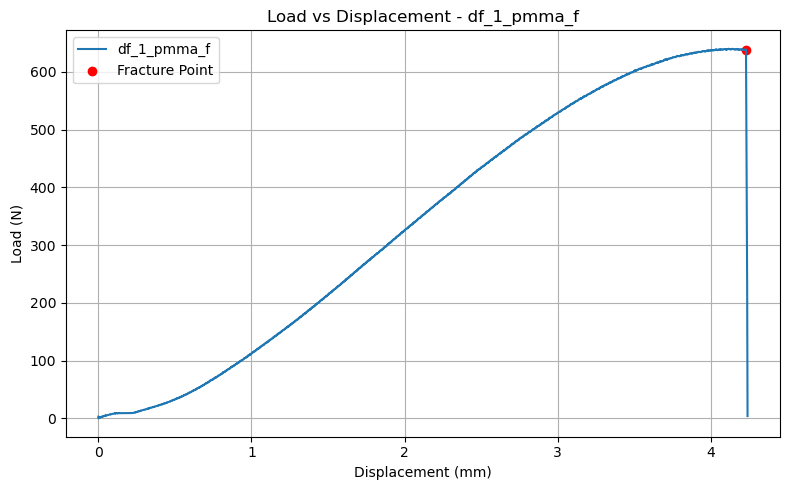

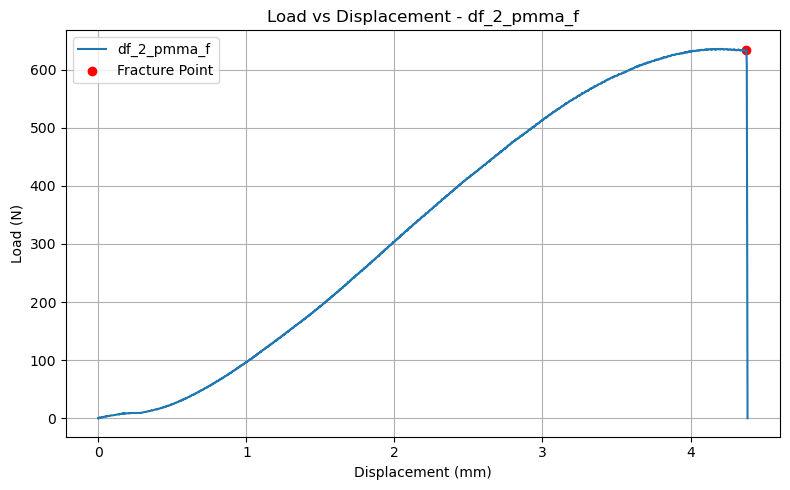

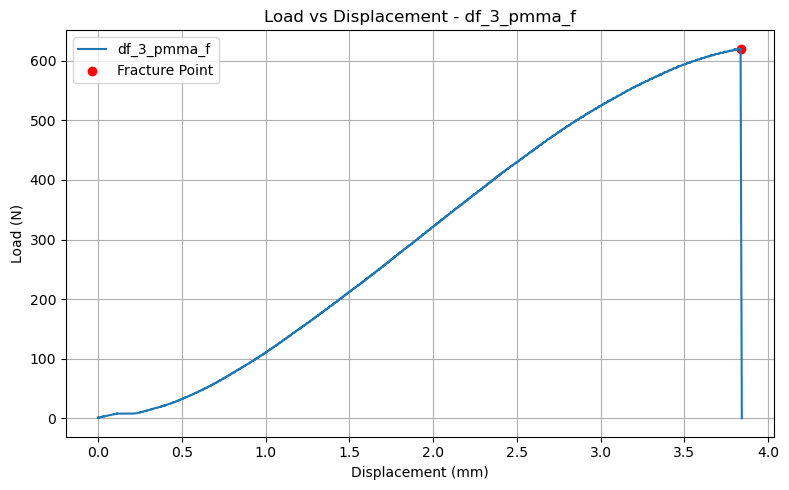

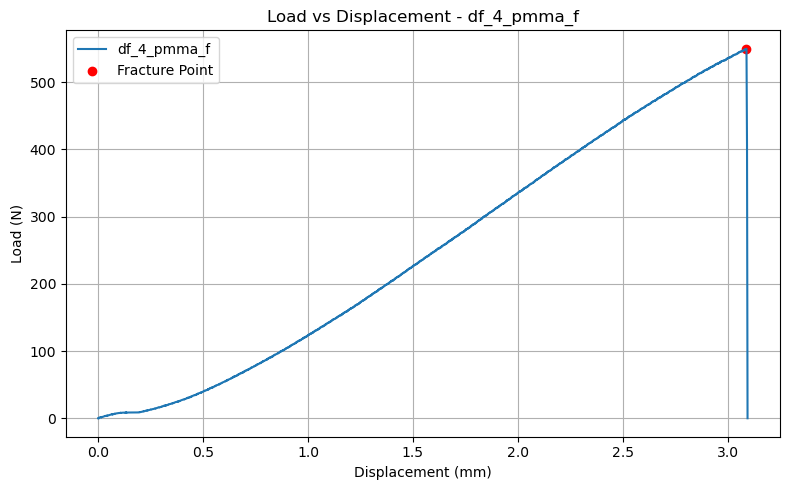

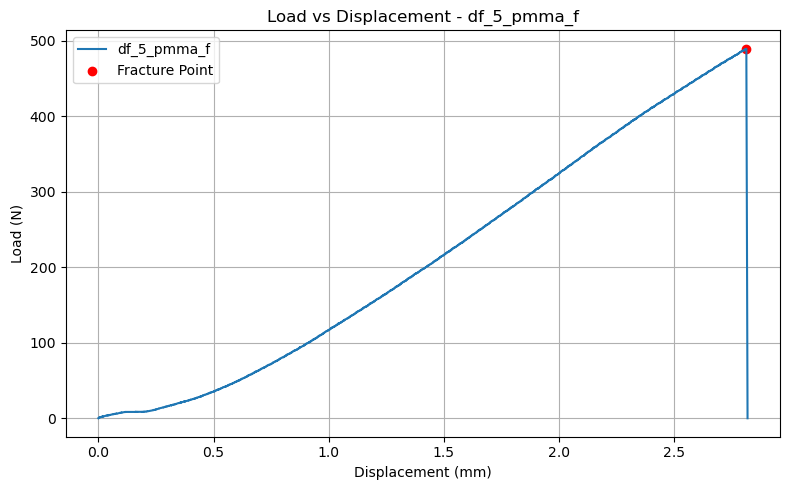

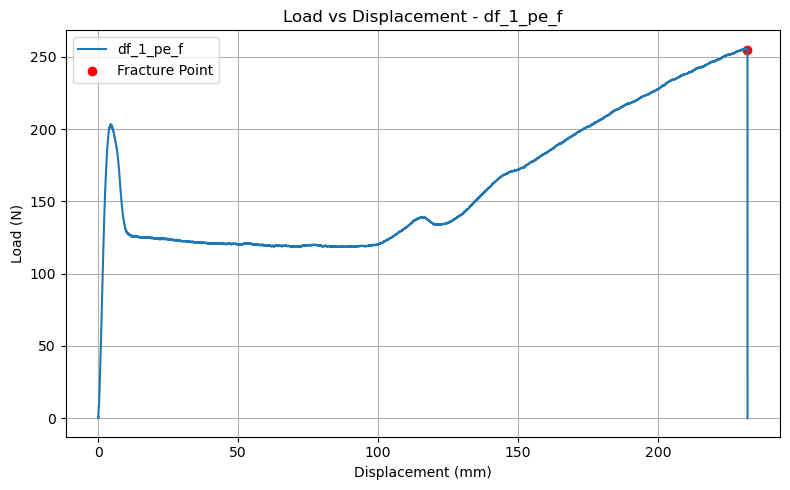

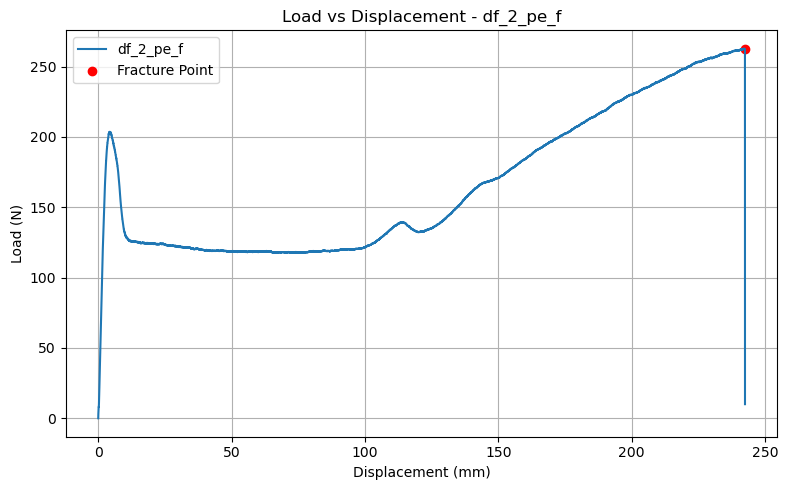

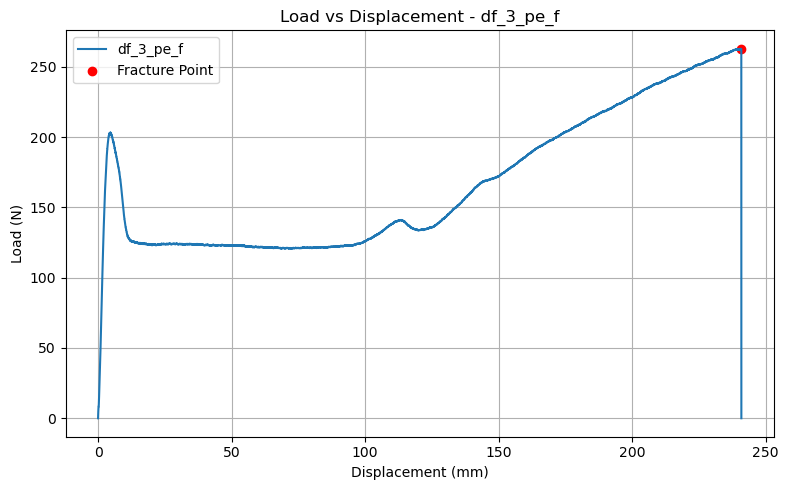

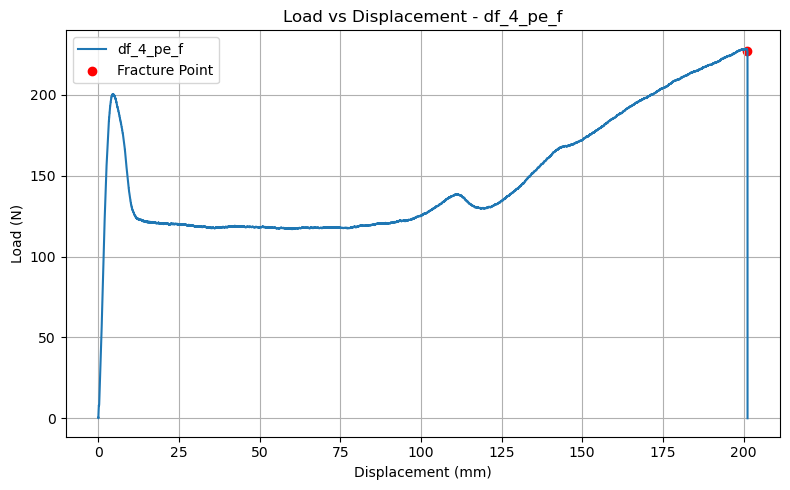

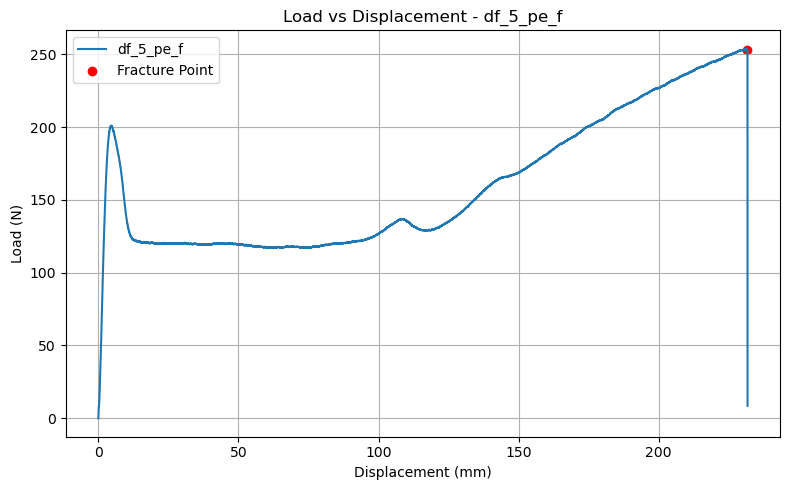

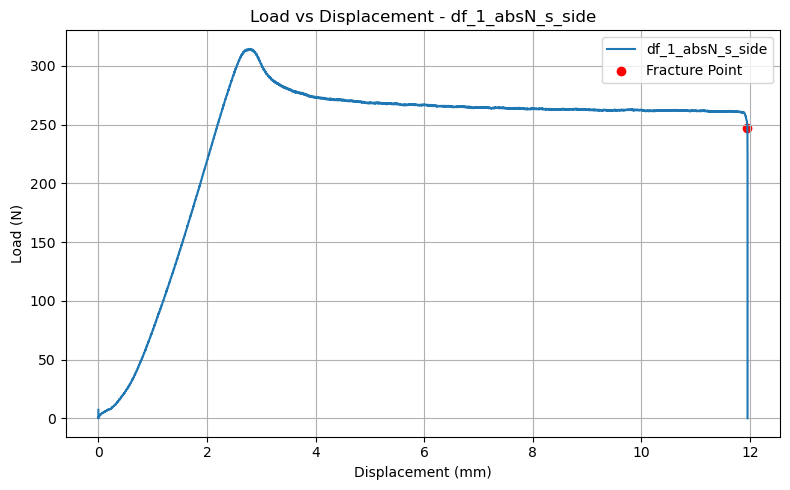

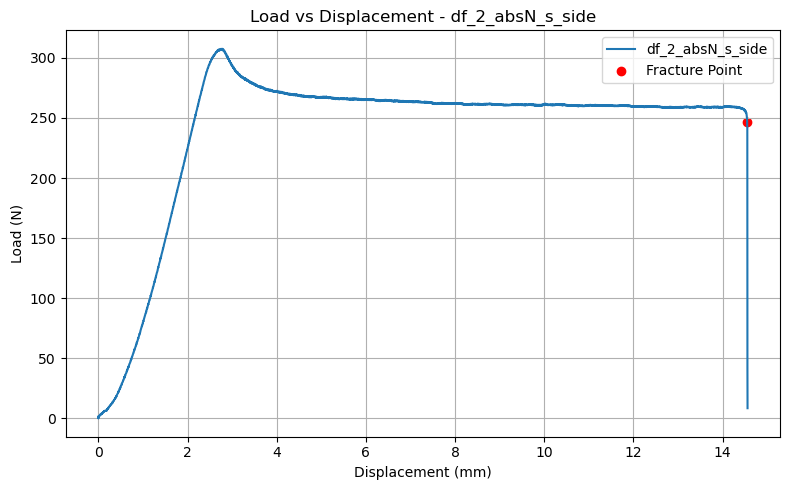

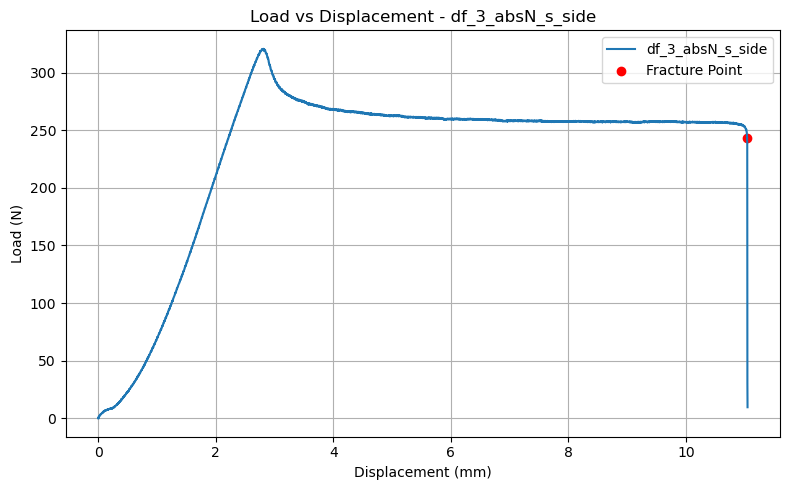

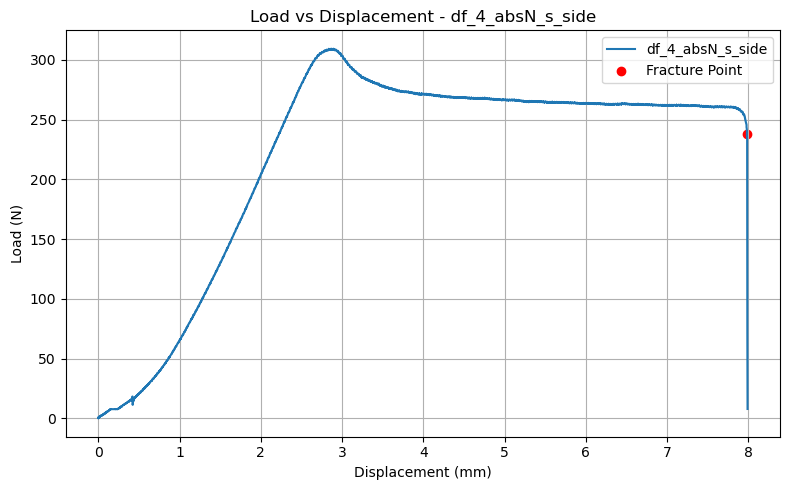

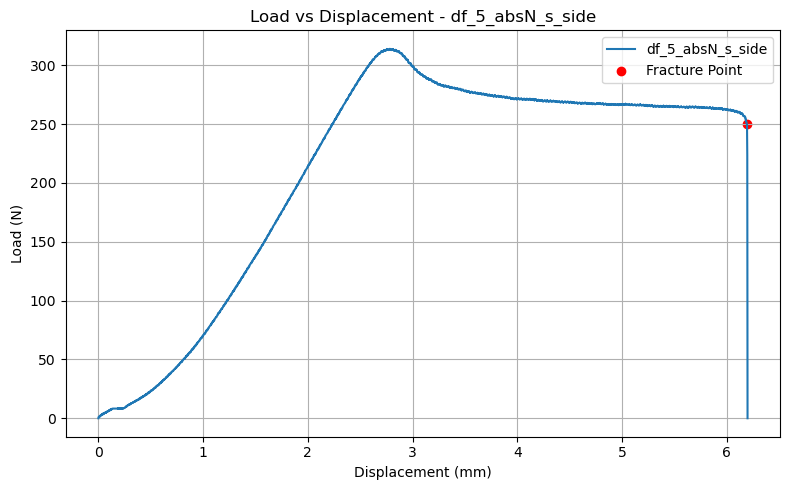

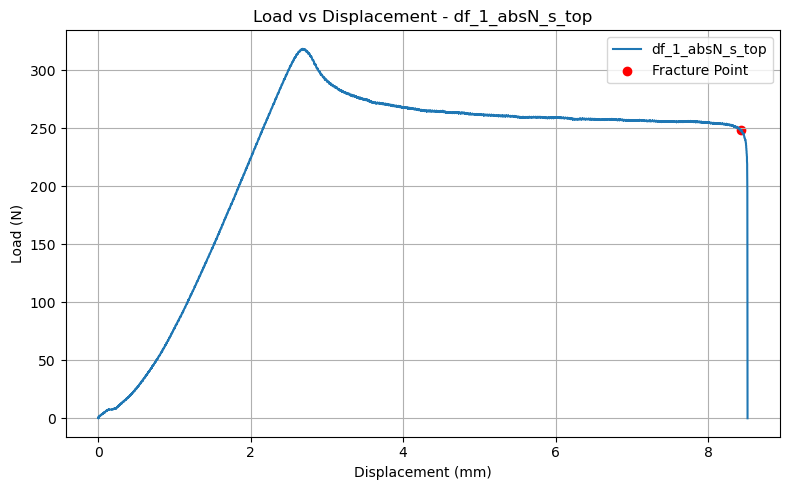

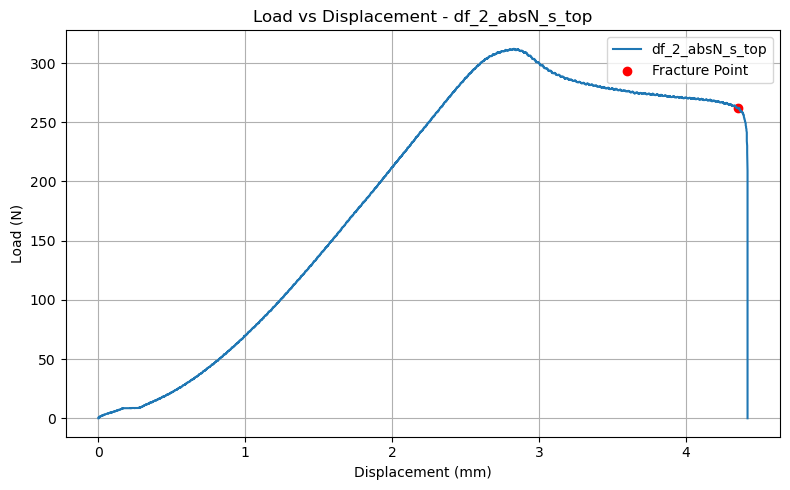

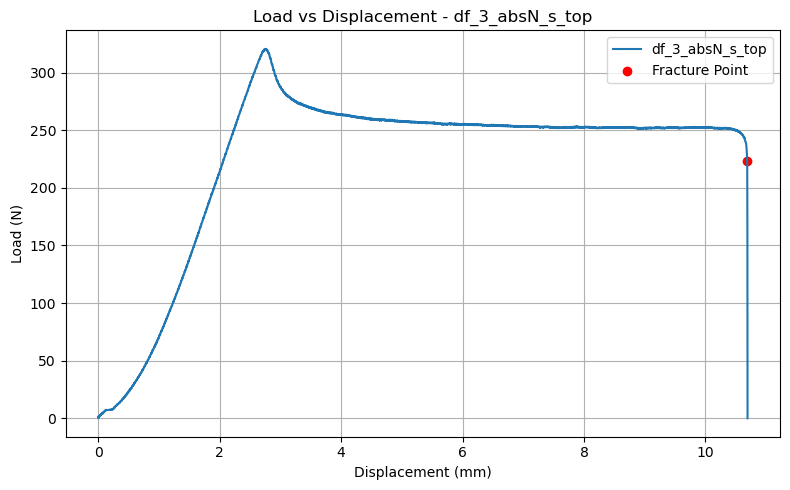

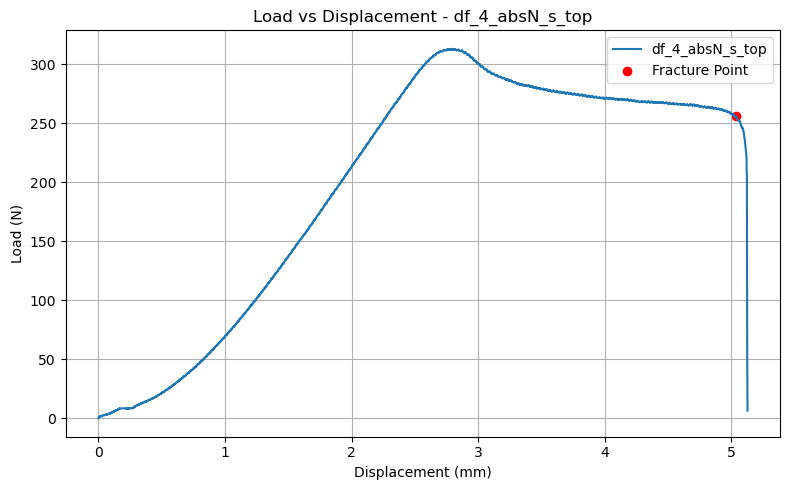

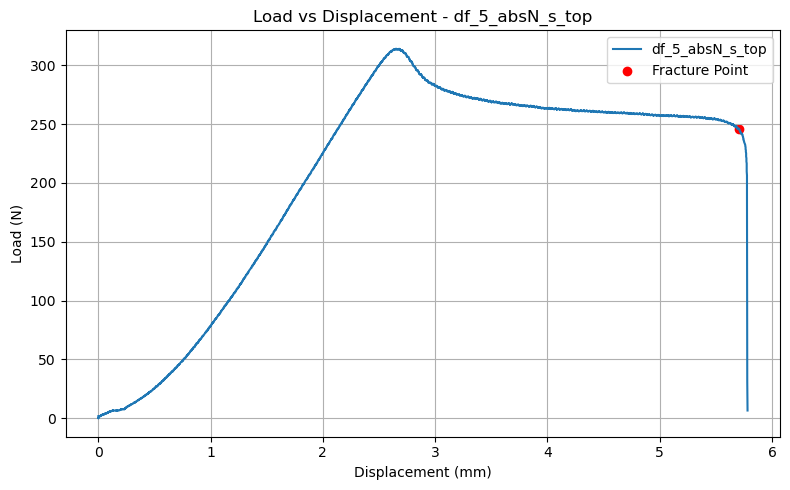

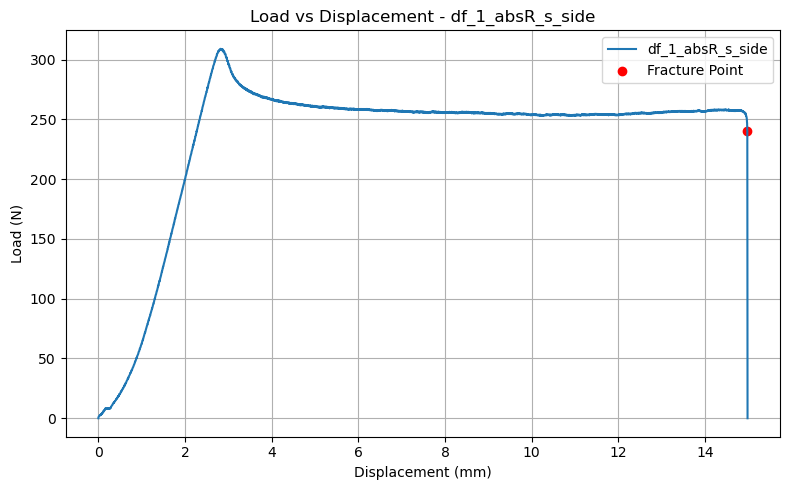

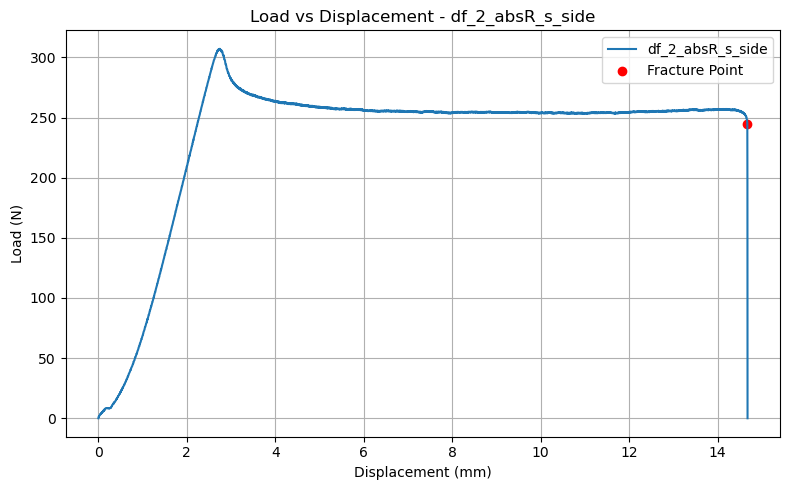

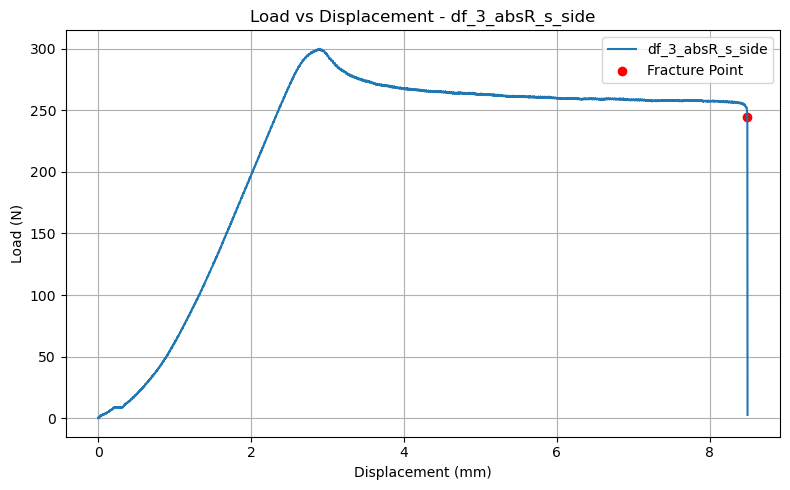

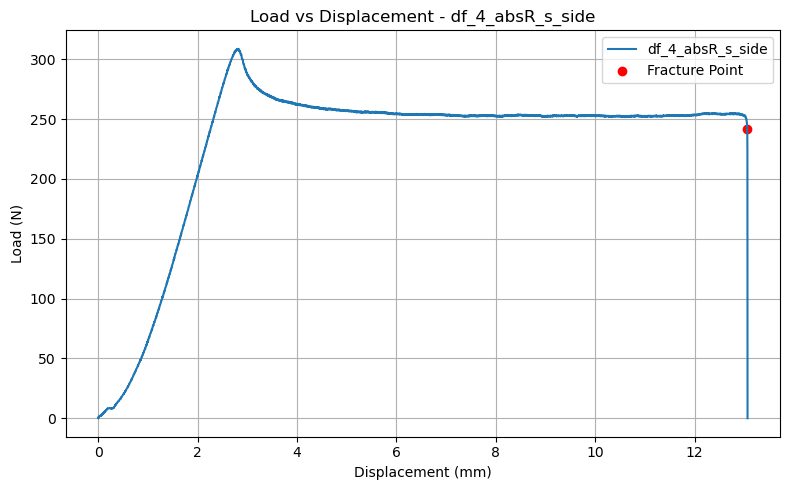

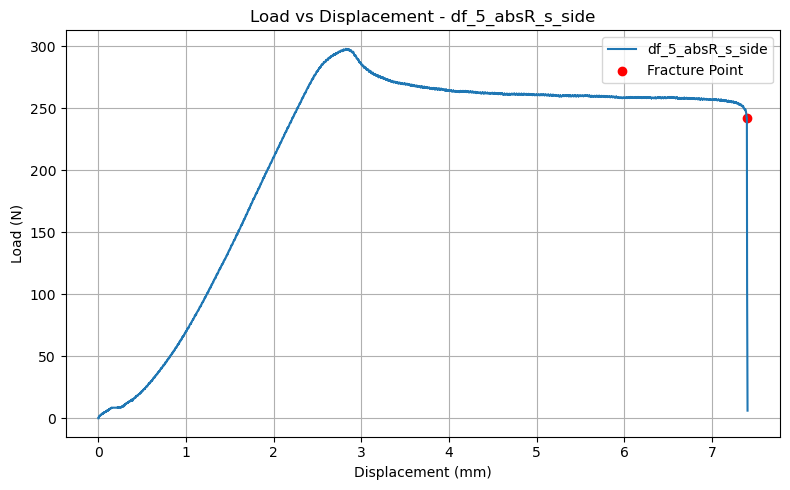

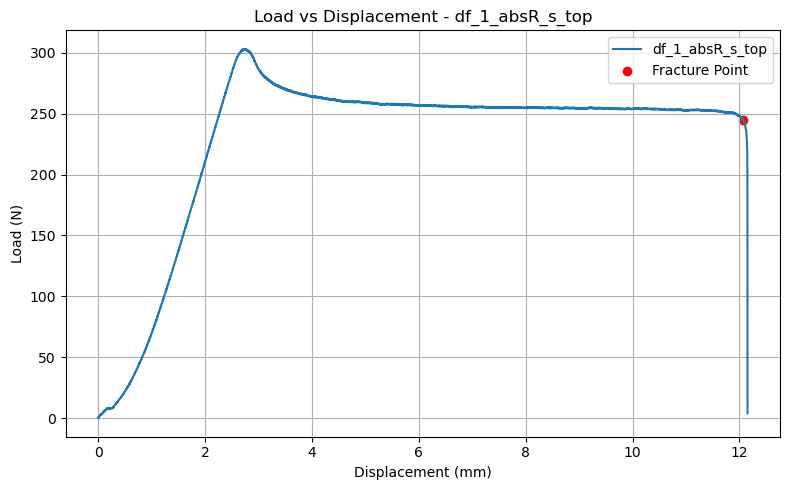

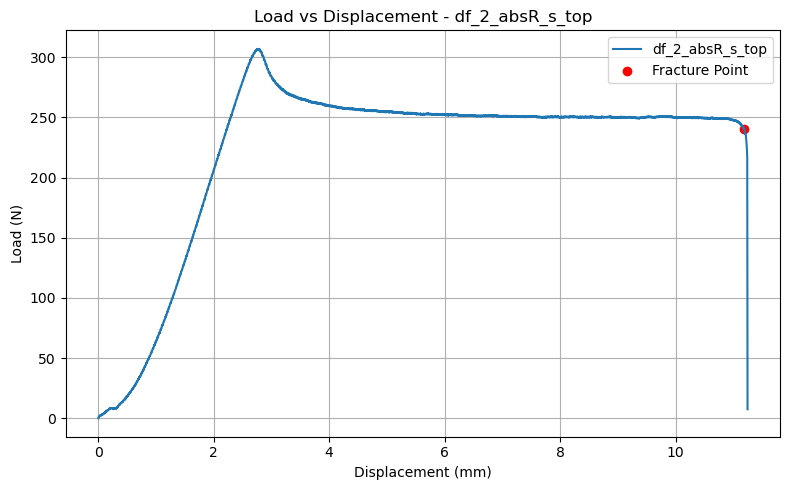

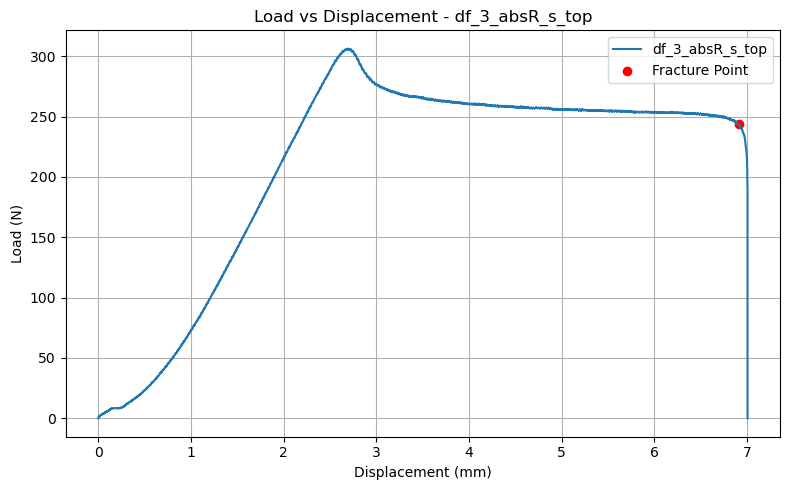

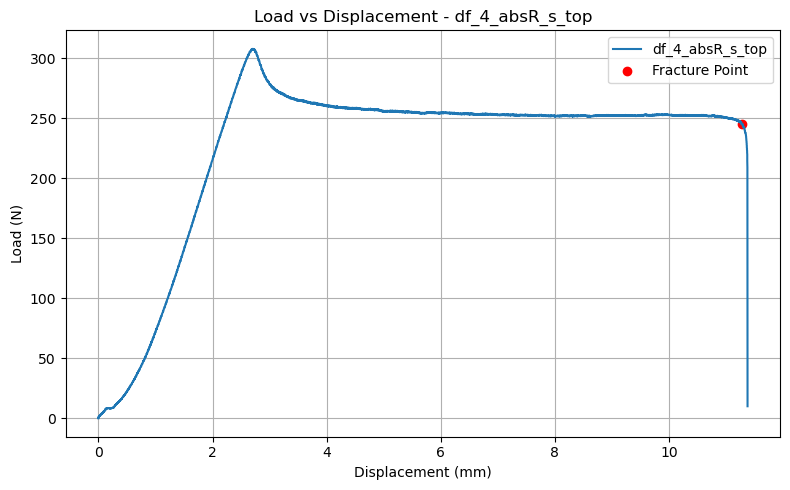

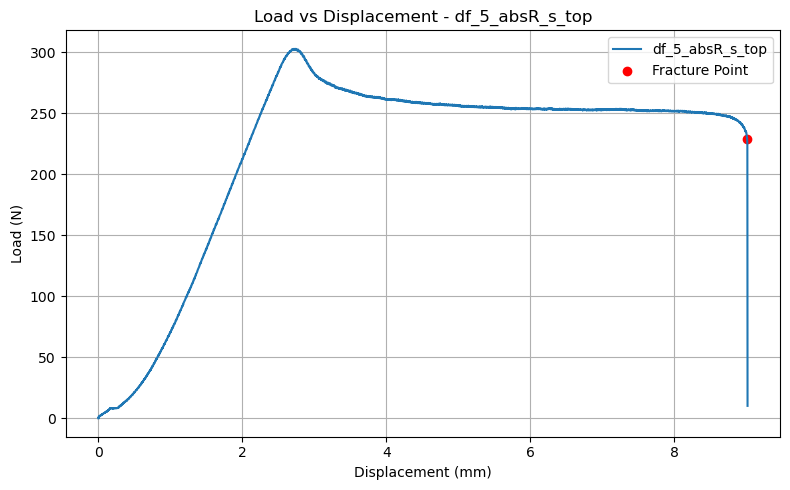

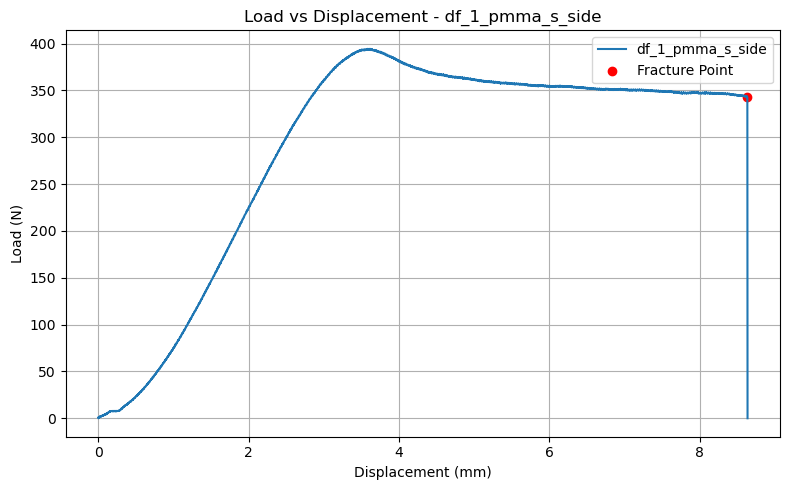

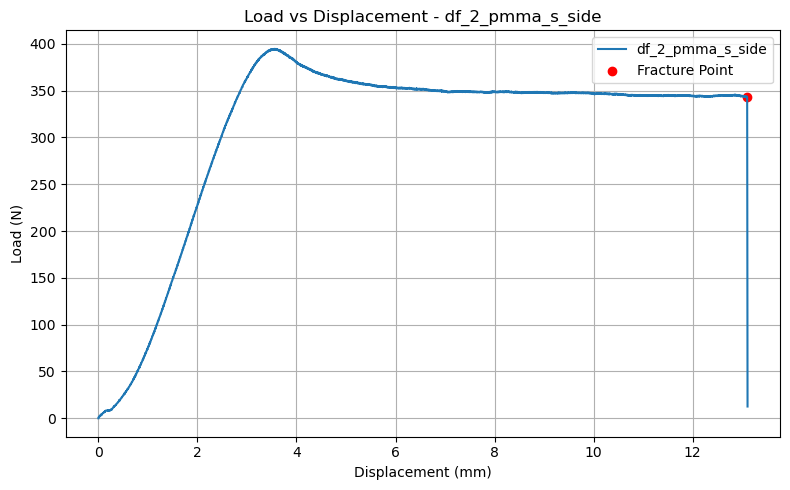

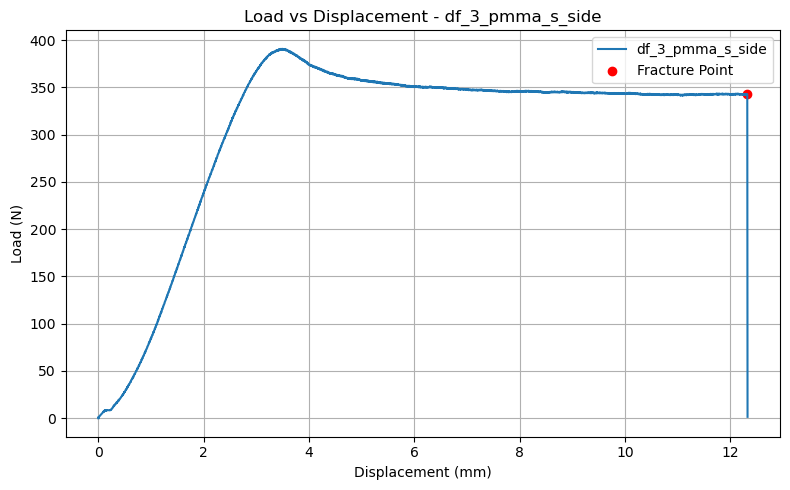

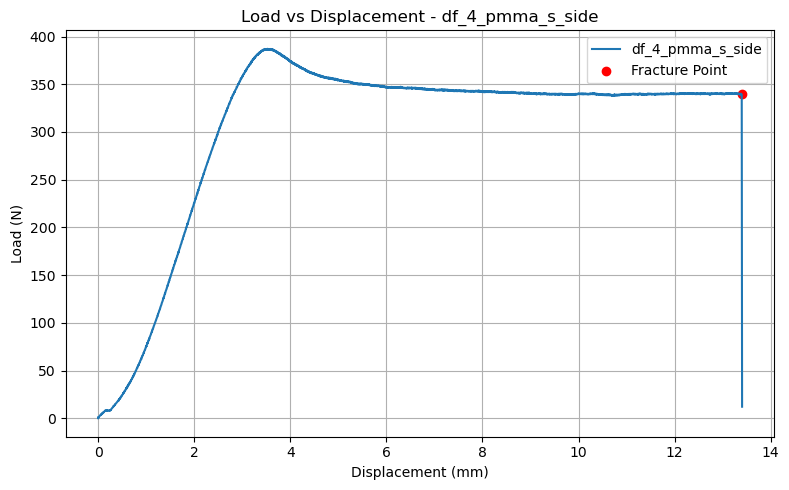

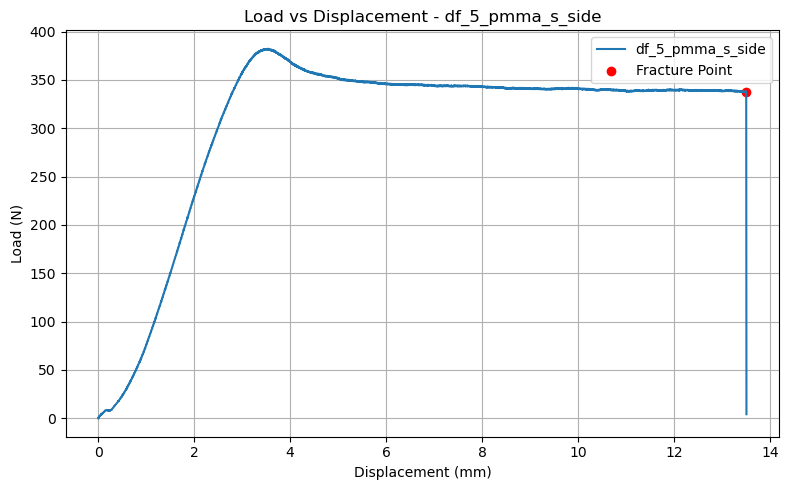

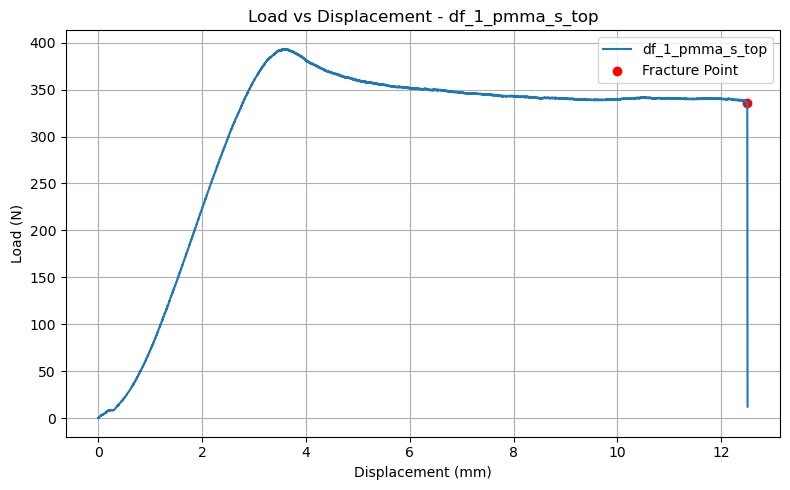

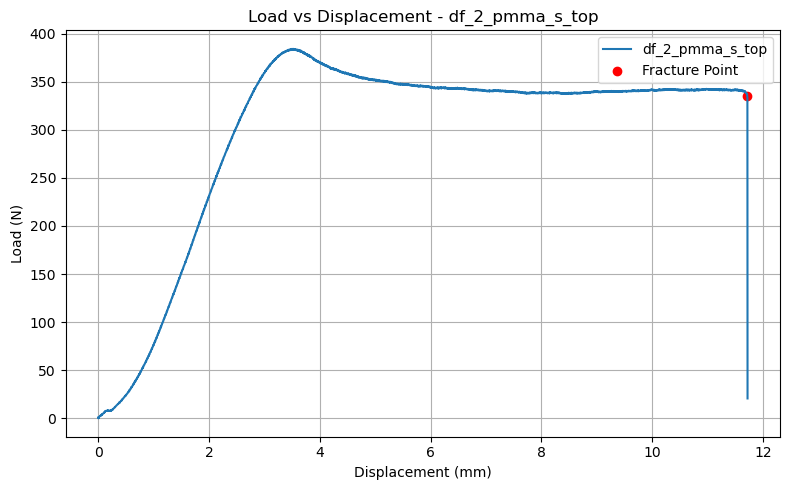

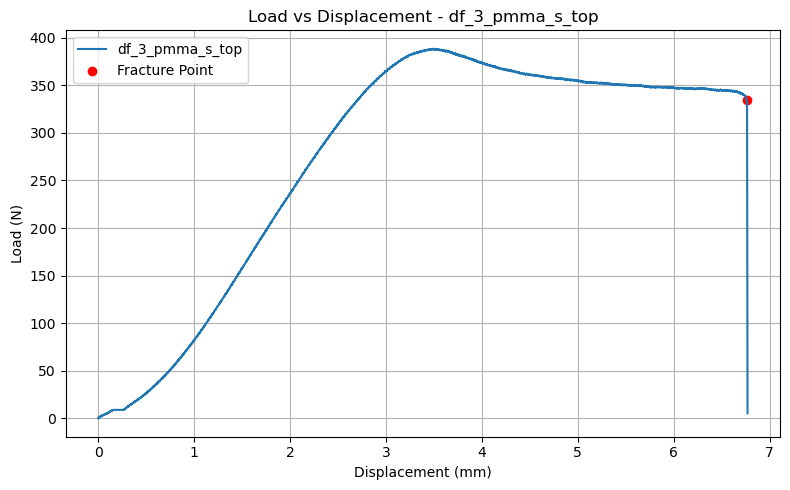

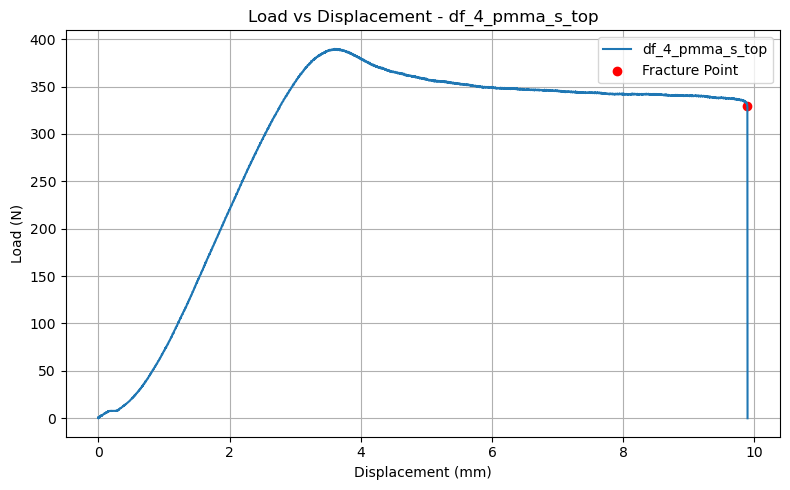

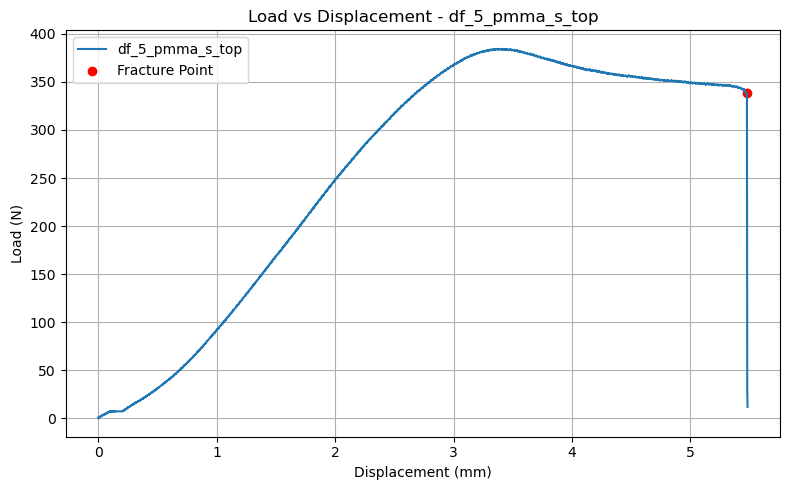

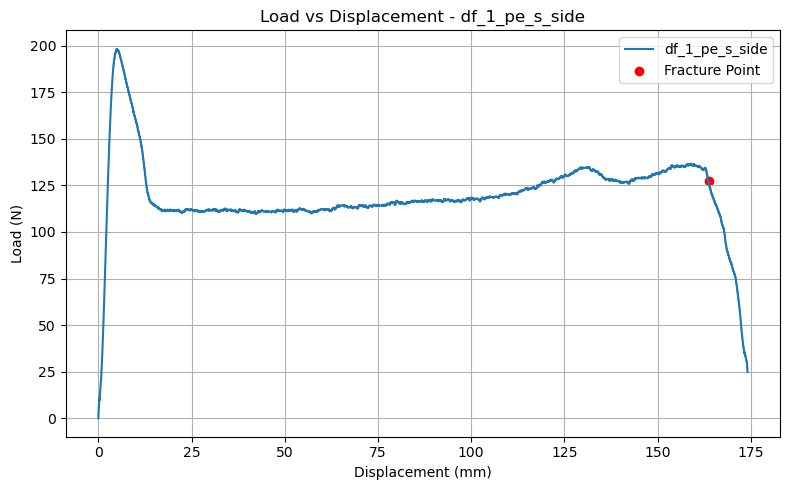

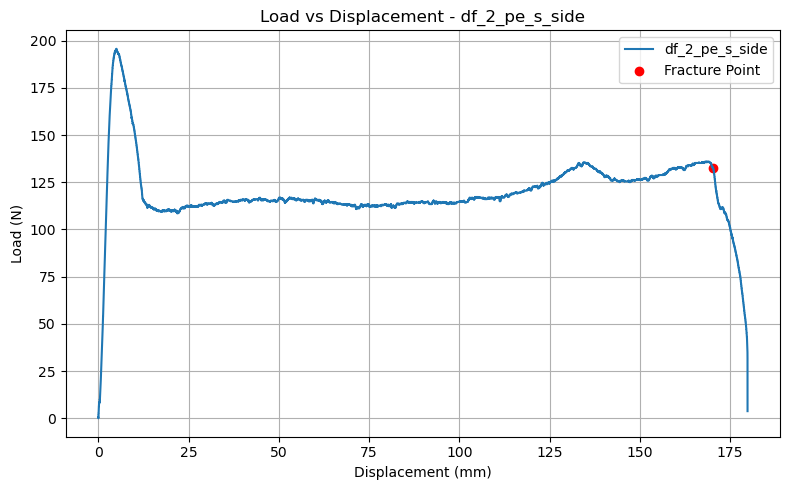

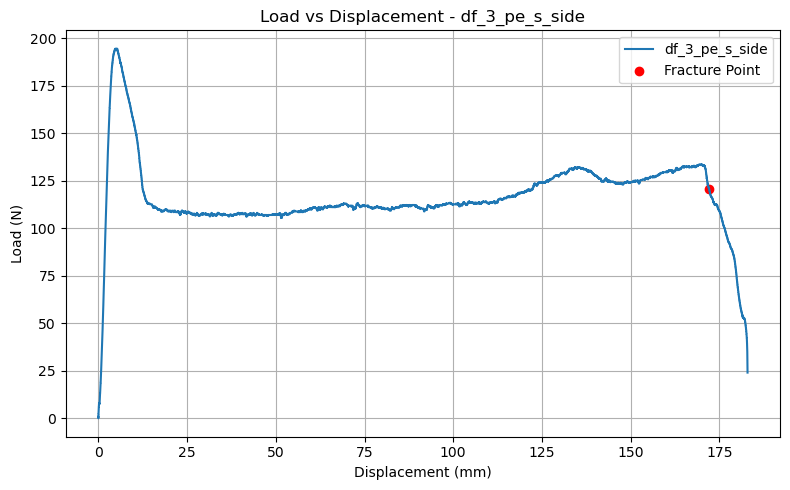

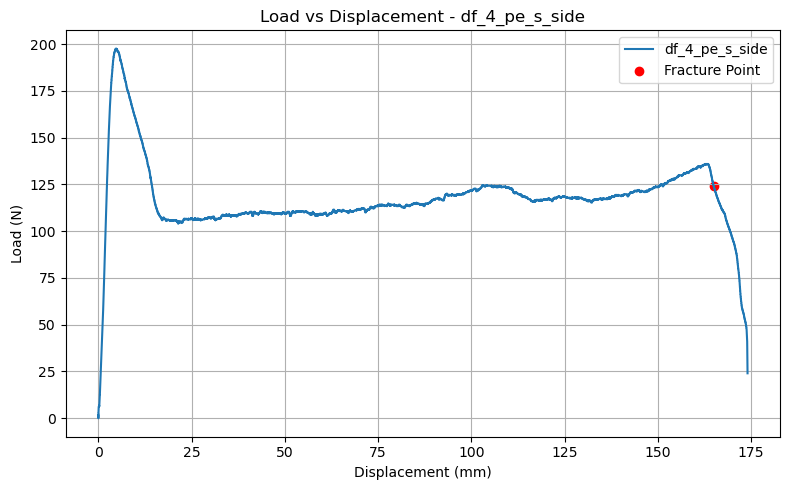

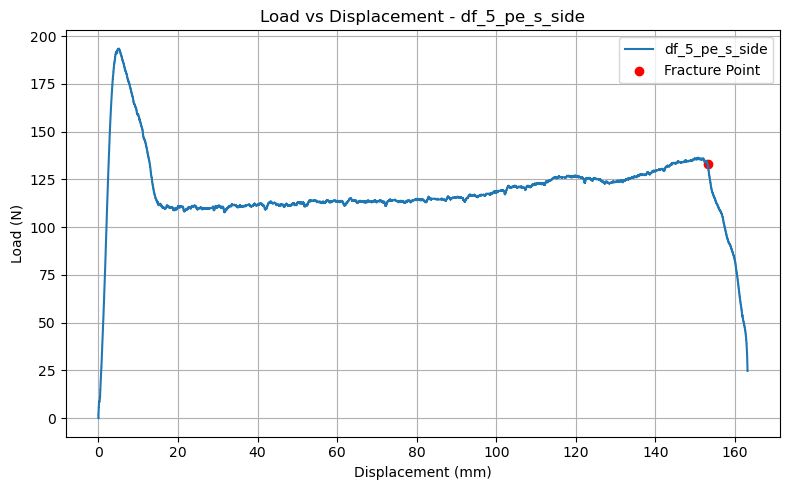

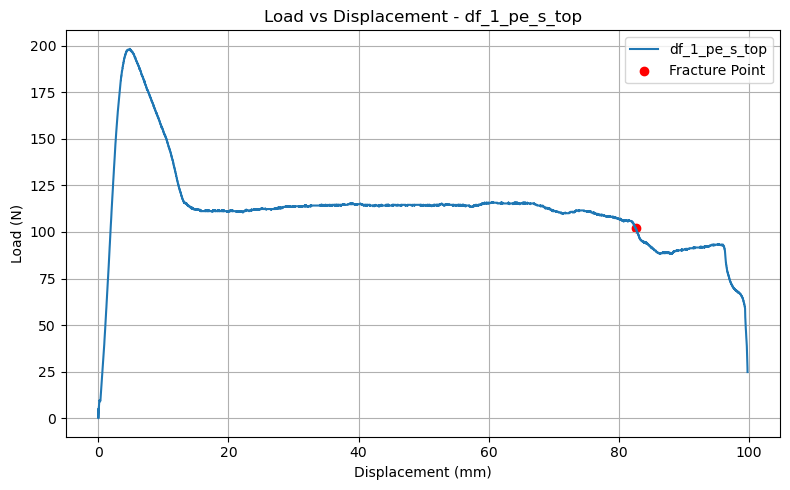

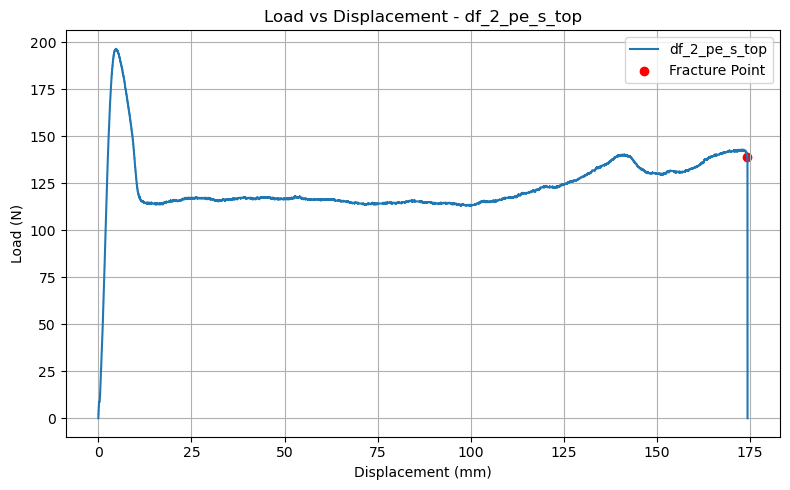

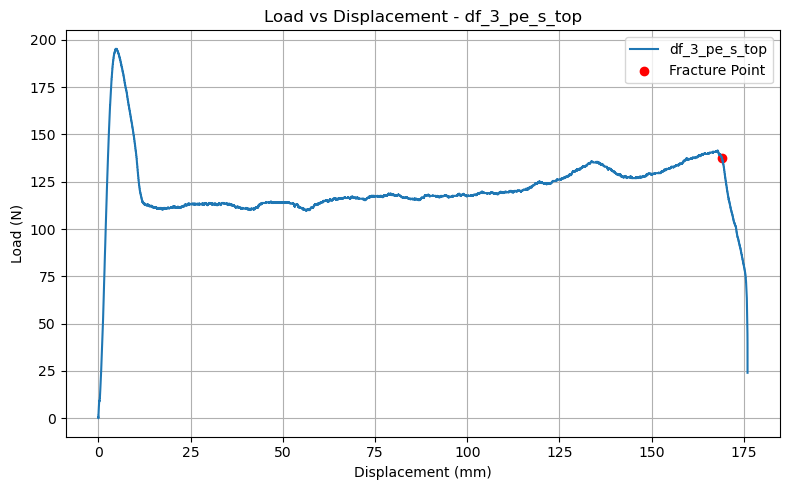

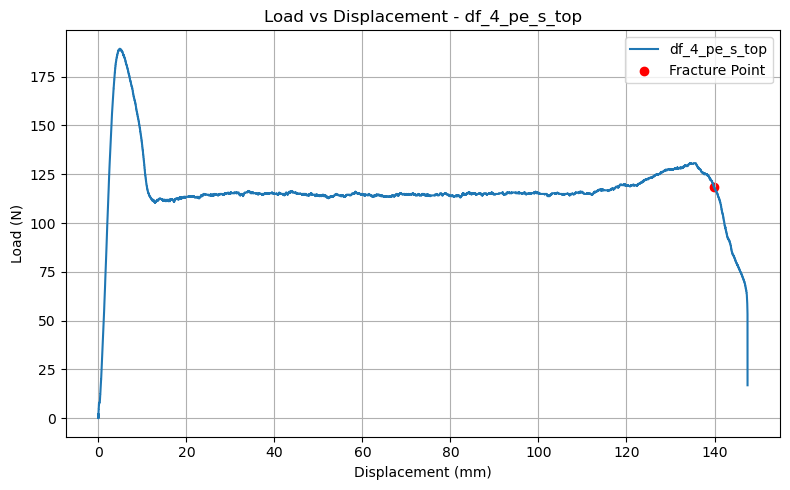

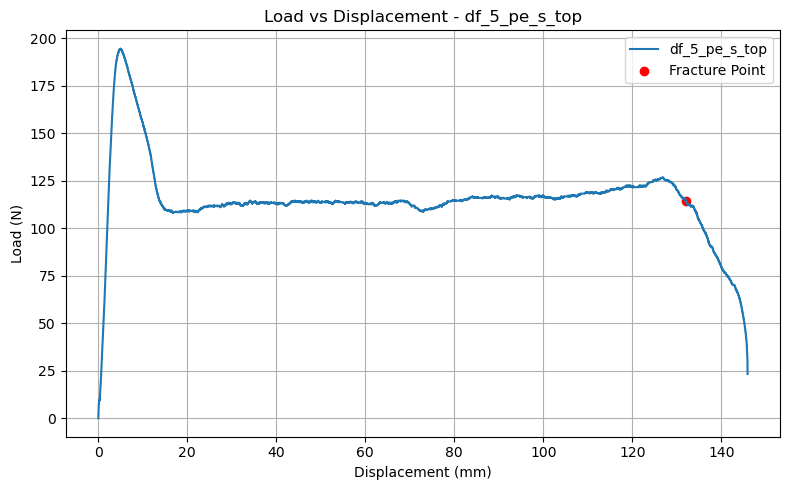

In [16]:
#plot fracture points on the plot in the plots folder

def plot_fracture_points(dfs, df_names, fracture_info, strain_col='Displacement', stress_col='Load', save=False):

    """
    Plot Load vs Displacement for each DataFrame and mark the fracture points.

    Args:
    - dfs (list of pd.DataFrame): List of DataFrames with Load vs Displacement data.
    - df_names (list of str): List of names corresponding to each DataFrame.
    - fracture_info (list of dict): Output from find_fracture_info function.
    - strain_col (str): Name of the displacement column (acts like strain).
    - stress_col (str): Name of the load column (acts like stress).
    - save (bool): Whether to save the plot as a PNG.
    """
    for df, name, info in zip(dfs, df_names, fracture_info):
        # Clean column names
        col_names = [col.strip().lower() for col in df.columns]

        try:
            load_idx = col_names.index(stress_col.lower())
            disp_idx = col_names.index(strain_col.lower())
        except ValueError as e:
            raise ValueError(f"Could not find '{stress_col}' or '{strain_col}' in columns: {df.columns}") from e

        # Extract and clean data
        data = df.iloc[:, [disp_idx, load_idx]].astype(float)
        data.columns = [strain_col, stress_col]

        # Plotting
        plt.figure(figsize=(8, 5))
        plt.plot(data[strain_col], data[stress_col], label=name)

        # Mark fracture point
        plt.scatter(info['fracture_strain'], info['fracture_stress'], color='red', label='Fracture Point')
        
        plt.xlabel("Displacement (mm)")
        plt.ylabel("Load (N)")
        plt.title(f"Load vs Displacement - {name}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        if save:
            plt.savefig(f"plots/fracture_points/{name}_fracture_point.png")
        plt.show()

plot_fracture_points(df_list, df_names, find_fracture_info(df_list, df_names), save=True)   